# Pre Simulation Testing

Now that we have created our input file we need to verify that our simulation parameters will give a good simulation.

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/documentation/Tutorial_NB/input_files/yukawa_mks_p3m.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/documentation/Tutorial_NB/Pre_Simulation_Testing.ipynb)



In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt

import os

# Choose the plot style MSUstyle or PUBstyle
plt.style.use('PUBstyle')

# Import sarkas
from sarkas.processes import PreProcess

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files', 'yukawa_mks_p3m.yaml')

## Simulation Parameters

Let's verify our input parameters

In [2]:
preproc= PreProcess()
preproc.setup(read_yaml=True, input_file=input_file_name)







 __            _             
/ _\ __ _ _ __| | ____ _ ___ 
\ \ / _` | '__| |/ / _` / __|
_\ \ (_| | |  |   < (_| \__ \
\__/\__,_|_|  |_|\_\__,_|___/
                             


An open-source pure-python molecular dynamics suite for non-ideal plasmas.



Estimating PPPM parameters...


********************************************************************************
                                 Preprocessing                                  
********************************************************************************

Job ID: yocp
Job directory: SarkasSimulations/yocp_pppm
PreProcessing directory: 
SarkasSimulations/yocp_pppm/PreProcessing

Equilibration dumps directory: 
SarkasSimulations/yocp_pppm/PreProcessing/Equilibration/dumps
Production dumps directory: 
SarkasSimulations/yocp_pppm/PreProcessing/Production/dumps

Equilibration H5MD file: 
SarkasSimulations/yocp_pppm/PreProcessing/Equilibration/dumps/yocp_data.h5md
Production H5MD file: 
SarkasSimulations/yocp_p

As you can see the output is rather verbose, so let's unpack it.

### Sarkas Figlet
The first screen output is the Sarkas Figlet. This is printed at the beginning of every process by the static method `screen_figlet()` of the `InputOutput` class. The Figlet font and colors are chosen randomly from a predefined set in `sarkas.utilities.io`. This function assumes a white background if you are running a Jupyter notebook, while a dark background in the case of an IPython/Python kernel.

### Storage
Next Sarkas prints the path where the snapshots (`dumps`) and the thermodynamics information of the simulation will be stored. Notice that these are in a directory called `SarkasSimulations/yocp_ppm/PreProcessing`. The actual simulation's dumps and energy files will be in a different directory, see next [page](./Simulation_Docs.ipynb). 

### PARTICLES
In this section we can find info about the particles we are simulating. Importantly we find the physical constants like the plasma frequency and Debye length.

### SIMULATION BOX
Next we have info on the simulation box with relevant lengths and parameters. These include the value of the Wigner-Seitz radius, ``a_ws``, the number of non zero dimensions, and the length of the simulation box sides in terms of ``a_ws`` and its numerical value in the chosen units. 

### ELECTRON PROPERTIES
This section prints thermodynamics quantities as well as dimensionless parameters of the surrounding electron liquid. Here we find the Thomas-Fermi length which is used for the screening parameter $\kappa$ of our Yukawa potential. Formulas for the calculation of each of these quantities can be found in the Electron Properties [page](../../theory/electron_properties.rst) in the Theoretical Background section.

### POTENTIAL
This section prints potential specific parameters. In the case of Yukawa we find the electron temperature used for the calculation of $\lambda_{\rm TF}$ and $\kappa = a_{ws}/\lambda_{\rm TF}$. 
The last line prints the coupling parameter as defined [here](../../theory/coupling_constant.rst)

### ALGORITHM
This section prints information about the choice of our algorithm for calculating the force between particles. The available algorithms are:
- `brute_force`: which consists in looping over all pair of particles. This is the slowest algorithm as it is $\mathcal O(N^2)$.
- `minimum_image`: which consists in calculating all pair of particles that have a distance less or equal than half the box length.
- `PP`: which consists in using a linked cell list to calculate the force between pair of particles that have a distance less or equal than `rc`.
- `PPPM`: the Particle-Particle Particle-Mesh algorithm. Sarkas uses a generalized P3M (or PPPM) algortihm to handle medium to long range interactions. More info can be found in our page on [PPPM](../../theory/PPPM.rst) and DSGM17 in [References](../../theory/references.rst).

There are two parts in this algorithm: particle-particle (PP) and particle-mesh (PM). The former consists of a Linked-Cell-List (LCL). The PM instead consists in depositing the charges on a mesh, move to Fourier space, solve Poisson equation on the mesh and get the electric field, inverse Fourier to return to real space, and finally use the calculated electric field to push the particles. 

As such this algorithm requires eleven (five in isotropic simulations) parameters: 
* the Ewald screening parameter `Potential.pppm_alpha_ewald` (1 scalar), 
* the number of mesh points per direction ``Potential.pppm_mesh`` (1 x 3 array), 
* the short-range cut-off `Potential.rc` (1 scalar),
* the charge assignment order ``Potential.pppm_cao`` (1 x 3 array), 
* the number of aliases of the Fast Fourier Transform (FFT) per direction, ``Potential.pppm_aliases`` (1 x 3 array).

These parameters have been estimated since we used `estimate_parameters` in the input file. The parameters have been estimated using some _hardcoded_ rules born from experience as such they are not perfect and as such we will have to optimize them for our purposes. 
<!-- 
Besides the choice of parameters Sarkas outputs the most relevant information for this algorithm: the number of cells per dimension for the LCL algorithm, the number of particles in the LCL loops, number of neighbors per particle, and the error in the force calculation. This is the error due to our choice of parameters. For more details on the way this is calculated see the page [Force Error](../../theory/force_error.rst). This number is dimensionless since all the variable have been rescaled.
There is no _good_ value for the Force error and it is up to YOU to decide. In Non-Ideal plasmas it is usually chosen to be less than ``1e-5``. In this case we have `Tot Force Error = 6.442673e-06`. 

Below we show how to choose all the above parameters to minimize the force error. -->

### THERMOSTAT
Next we find information about the thermostat used. At the moment Sarkas supports the Berendsen thermostat only. You can learn more about it on this [page](../Features_files/Berendsen_NB/Berendsen_Thermostat.ipynb).
The parameter `relaxation_timestep` tells us the timestep number at which the thermostat will be turned on. Before then the system will evolve at constant energy. A good number for this is the timestep equivalent to 1 or 2 plasma periods as this allows the system to convert most of its potential energy into kinetic energy and thus reaching its maximum value. Turning on the thermostat once the kinetic energy is maximal is the most efficient way to thermalize.

### INTEGRATOR
The last section prints out info about our choice of Integrator and about the timing of the phases of our simulation. The most important parameters here are the `Total plasma frequency` and `w_p dt`. The total plasma frequency is calculated from 

$$ \omega_{\rm tot} = \left [ \sum_i \omega_i^2 \right ]^{1/2} $$

where $\omega_i$ is the plasma frequency of species $i$. In the case of a one component plasma, as in this case, the total plasma frequency is the same as the plasma frequency printed in the `PARTICLES` section above.
The number `w_p dt` tells us the fraction of inverse plasma frequencies that corresponds to our choice of `dt`. A non-written rule among researchers says that we should choose a `dt` such that $\omega_p dt < 1/ 25$.

### Initialization Times
In this section are indicated the times for the initialization part of the simulation. These times are

- `Potential Initialization` where the all the potential parameters, including the Optimal Green's function in the case of PPPM algorithm, are calculated.
- `Particles Initialization` where the particles positions and velocities are initialized. This includes the case where a specific particles distribution is chosen.

Al of the above output is intended to be a check on the choice of parameters. The real advantage of using `PreProcess` comes next.

In [3]:
from IPython import get_ipython

# if get_ipython().__class__.__name__ == "ZMQInteractiveShell":
#     from tqdm import tqdm.notebook as tqdm
#     from tqdm.notebook import trange
# else:
from tqdm.notebook import tqdm

from numpy import (
    arange,
    array,
    full,
    int64,
    linspace,
    log2,
    log10,
    logspace,
    meshgrid,
    pi,
    sqrt,
    zeros,
)
from os import listdir, mkdir
from os import remove as os_remove
from os import stat as os_stat
from os.path import exists, join
from pandas import DataFrame, read_csv
from seaborn import scatterplot, kdeplot
from warnings import warn

from sarkas.utilities.maths import force_error_analytic_pp, force_error_approx_pm

def timing_study_calculation(self, target_error=1e-5, pp_cells=None, pm_meshes=None, pm_caos=None, method="brute_force"):
    """
    Estimate optimal PPPM parameters balancing accuracy and performance.
    
    Parameters
    ----------
    target_error : float, optional
        Target force error tolerance. If provided, will find fastest configuration meeting this error. Default is 1e-5.
    pp_cells : numpy.ndarray, optional
        Array of cells for PP calculations. If None uses the attribute :attr:`PreProcess.pp_cells`.
    pm_meshes : numpy.ndarray, optional
        Array of mesh sizes for PM calculations. If None uses the attribute :attr:`PreProcess.pm_meshes`.
    pm_caos : numpy.ndarray, optional
        Array of charge assignment orders. If None uses the attribute :attr:`PreProcess.pm_caos`.
    method : str, optional
        Method for parameter optimization: "brute_force" or "automated". Default is "brute_force".
    
    Returns
    -------
    dict
        Dictionary containing the optimal parameters and Pareto-optimal configurations.
    
    Notes
    -----
    User-provided parameters are saved as attributes (self.user_pp_cells, 
    self.user_pm_meshes, self.user_pm_caos) and are respected without modification. 
    """
    # Setup directories for outputs
    self.pppm_plots_dir = join(self.io.directory_tree["preprocessing"]["path"], "PPPM_Plots")
    if not exists(self.pppm_plots_dir):
        mkdir(self.pppm_plots_dir)

    msg = "\n\n{:=^70} \n".format(f" PPPM Parameter Optimization ({method}) ")
    self.io.write_to_logger(msg)

    # Store original values to restore later
    self.input_rc = self.potential.rc
    self.input_mesh = self.potential.pppm_mesh.copy()
    self.input_alpha = self.potential.pppm_alpha_ewald
    self.input_cao = self.potential.pppm_cao.copy()
    self.input_aliases = self.potential.pppm_aliases.copy()

    # Calculate maximum allowed cells based on minimum particle separation
    max_cells = int(0.5 * self.parameters.box_lengths.min() / self.parameters.a_ws)
    
    # Rescaling constant for PP force error calculation
    rescaling_constant = (
        sqrt(self.potential.total_num_ptcls) * self.potential.a_ws**2 / 
        sqrt(self.potential.pbox_volume)
    )
    
    # Choose optimization method
    if method.lower() == "automated":
        return None #_automated_parameter_selection(target_error, rescaling_constant, max_cells)
    else:  # Default to brute force
        return _brute_force_parameter_selection(preproc, pp_cells, pm_meshes, pm_caos, target_error, max_cells)

def _brute_force_parameter_selection(self, pp_cells=None, pm_meshes=None, pm_caos=None, 
                                    target_error=None, max_cells=None, show_plot=True):
    """
    Perform brute force parameter sweep to find optimal PPPM parameters.
    
    Parameters are the same as timing_study_calculation.
    """
    # Save user inputs in self attributes for reference
    if pp_cells is not None:
        self.pp_cells = pp_cells.copy() if hasattr(pp_cells, 'copy') else pp_cells
    if pm_meshes is not None:
        self.pm_meshes = pm_meshes.copy() if hasattr(pm_meshes, 'copy') else pm_meshes
    if pm_caos is not None:
        self.pm_caos = pm_caos.copy() if hasattr(pm_caos, 'copy') else pm_caos
    
    # Use provided parameters or defaults
    if pp_cells is None:
        # If no user input, calculate based on max_cells, but respect original defaults
        if max_cells is not None and max_cells > self.pp_cells[-1]:
            pp_cells = arange(3, max_cells, dtype=int)
        else:
            pp_cells = self.pp_cells
    # User input is respected - we don't modify it based on max_cells
        
    if pm_meshes is None:
        pm_meshes = self.pm_meshes
    if pm_caos is None:
        pm_caos = self.pm_caos

    # Data collection for all parameter combinations
    data = []

    # Progress tracking for all parameter combinations
    total_combinations = len(pm_meshes) * len(pm_caos) * len(pp_cells)
    progress = tqdm(total=total_combinations, 
                desc="Testing PPPM parameter combinations", 
                disable=not self.parameters.verbose)

    # Start the parameter sweep
    for _, m in enumerate(pm_meshes):
        # Setup PM params
        self.potential.pppm_mesh = full(3, m, dtype=int)
        self.potential.pppm_alpha_ewald = 0.3 * m / self.potential.box_lengths.min()
        self.potential.pppm_h_array = self.potential.box_lengths / self.potential.pppm_mesh

        for _, cao in enumerate(pm_caos):
            self.potential.pppm_cao = full(3, cao, dtype=int)
            
            # Update potential parameters
            self.potential.pot_update_params(self.potential, self.species)
            
            # Calculate Green's function and PM error
            green_time = self.green_function_timer()

            # Measure PM acceleration time (average of 3 runs)
            pm_acc_time = 0.0
            for it in range(3):
                self.timer.start()
                self.potential.update_pm(self.particles)
                pm_acc_time += self.timer.stop() / 3.0

            # For each cutoff radius option
            for _, cell in enumerate(pp_cells):
                # Update progress bar
                progress.update(1)
                
                # Set cutoff radius based on cell size
                self.potential.rc = self.potential.box_lengths.min() / cell

                # Calculate PPPM error approximation
                self.potential.calculate_force_error()

                # Measure PP acceleration time (average of 3 runs)
                pp_acc_time = 0.0
                for it in range(3):
                    self.timer.start()
                    self.potential.update_linked_list(self.particles)
                    pp_acc_time += self.timer.stop() / 3.0

                # Total acceleration time
                total_acc_time = pp_acc_time + pm_acc_time
                
                # Error metrics
                pp_pm_ratio = self.potential.pppm_pp_err / self.potential.pppm_pm_err

                # Store all the data
                data_row = [
                    cell,
                    self.potential.rc,
                    self.potential.pppm_alpha_ewald,
                    self.potential.pppm_cao[0],
                    self.potential.pppm_cao[1],
                    self.potential.pppm_cao[2],
                    self.potential.pppm_mesh[0],
                    self.potential.pppm_mesh[1],
                    self.potential.pppm_mesh[2],
                    self.potential.pppm_mesh.prod(),
                    self.potential.pppm_h_array[0],
                    self.potential.pppm_h_array[1],
                    self.potential.pppm_h_array[2],
                    self.potential.pppm_h_array.prod(),
                    self.potential.pppm_h_array[0] * self.potential.pppm_alpha_ewald,
                    self.potential.pppm_h_array[1] * self.potential.pppm_alpha_ewald,
                    self.potential.pppm_h_array[2] * self.potential.pppm_alpha_ewald,
                    self.potential.pppm_h_array.prod() * self.potential.pppm_alpha_ewald**3,
                    green_time * 1.0e-9,
                    pp_acc_time * 1.0e-9,
                    pm_acc_time * 1.0e-9,
                    total_acc_time * 1.0e-9,                        
                    self.potential.pppm_pp_err,
                    self.potential.pppm_pm_err,
                    self.potential.force_error,
                    self.potential.pppm_pm_err_approx,
                    self.potential.force_error_approx,
                    pp_pm_ratio,  # Added PP/PM error ratio
                ]
                data.append(data_row)

    # Close progress bar
    progress.close()

    # Create DataFrame with all results
    column_names = [
        "pp_cells",
        "r_cut",
        "pppm_alpha_ewald",
        "pppm_cao_x",
        "pppm_cao_y",
        "pppm_cao_z",
        "M_x",
        "M_y",
        "M_z",
        "Mesh volume",
        "h_x",
        "h_y",
        "h_z",
        "h_M volume",
        "h_x alpha",
        "h_y alpha",
        "h_z alpha",
        "h_M a_ws^3",
        "G_k time [s]",
        "pp_acc_time [s]",
        "pm_acc_time [s]",
        "tot_acc_time [s]",
        "pppm_pp_error [measured]",
        "pppm_pm_error [measured]",
        "force error [measured]",
        "pppm_pm_error [approx]",
        "force error [approx]",
        "pp_pm_error_ratio"  # Added PP/PM error ratio
    ]

    self.dataframe = DataFrame(data, columns=column_names)
    csv_location = join(self.io.directory_tree["preprocessing"]["path"], 
                        f"TimingStudy_data_{self.io.job_id}.csv")
    self.dataframe.to_csv(csv_location, index=False)

    # Find and save Pareto-optimal configurations
    pareto_points, best_point = find_pareto_optimal_configs(preproc, self.dataframe, target_error=target_error)
    
    # Plot Pareto frontier
    if show_plot:
        plot_error_vs_performance(preproc, self.dataframe, pareto_points, best_point)

    # Run the pppm_estimate for the best parameters
    self.potential.rc = best_point["r_cut"]
    self.potential.pppm_mesh = best_point[["M_x", "M_y", "M_z"]].values.astype(int) 
    self.potential.pppm_alpha_ewald = best_point["pppm_alpha_ewald"]
    self.potential.pppm_cao = best_point[["pppm_cao_x", "pppm_cao_y", "pppm_cao_z"]].values.astype(int)
    self.potential.estimate_parameters = False
    self.potential.setup(self.parameters, self.species)
    self.pppm_approximation()

    # Reset to original values
    # self.potential.rc = self.input_rc
    # self.potential.pppm_mesh = self.input_mesh.copy()
    # self.potential.pppm_alpha_ewald = self.input_alpha
    # self.potential.pppm_cao = self.input_cao.copy()
    # # Set up potential with original parameters 
    # self.potential.estimate_parameters = False
    
            
    # Report file locations
    msg = (
        f"\nResults saved to:\n"
        f"  Full parameter sweep data: {csv_location}\n"
        f"  Pareto-optimal configurations: {join(self.io.directory_tree['preprocessing']['path'], f'Pareto_optimal_PPPM_{self.io.job_id}.csv')}\n"
        f"  Visualizations: {self.pppm_plots_dir}"
    )
    if self.parameters.verbose:
            print(msg)
    self.io.write_to_logger(msg)
  
def find_pareto_optimal_configs(self, configuration_df = None, target_error=1e-5):
    """
    Find the Pareto-optimal configurations (those where error or time cannot 
    be improved without worsening the other).
    
    Parameters
    ----------
    configuration_df : pandas.DataFrame, optional
        DataFrame containing the configuration data. If None, uses self.dataframe.

    target_error : float
        Target force error tolerance. Default is 1e-5.

    Returns
    -------
    list
        List of Pareto-optimal parameter configurations
    
    dict
        Dictionary containing the best configuration found.
    """
    if configuration_df is None:
        configuration_df = self.dataframe
    
    pareto_points = []
    for _, row in configuration_df.iterrows():
        # Check if this point is dominated by any other point
        dominated = False
        for _, other_row in configuration_df.iterrows():
            # Point i is dominated by point j if j has better (lower) time AND error
            # Or if one is equal and the other is better
            if (other_row['tot_acc_time [s]'] <= row['tot_acc_time [s]'] and 
                other_row['force error [measured]'] < row['force error [measured]'] and
                (other_row['tot_acc_time [s]'] < row['tot_acc_time [s]'] or 
                other_row['force error [measured]'] <= row['force error [measured]'])):
                dominated = True
                break
        
        if not dominated:
            pareto_points.append(row)
    
    # Sort by error
    pareto_points = sorted(pareto_points, key=lambda x: x['force error [measured]'])
    
    # Find absolute best configuration 
    if len(pareto_points) > 0:
        
        # Find the best configuration by finding the points which are less the force_error and then choosing the points with the smallest time
        force_points = [point for point in pareto_points if point['force error [measured]'] <= target_error]
        best_point = min(force_points, key=lambda x: x['tot_acc_time [s]'])    
        
        # Report only the best configuration
        msg = (
            f"\nOPTIMAL PPPM CONFIGURATION:\n"
            f"  Target Error: {target_error:.6e}\n"
            f"  PP Cells: {int(best_point['pp_cells'])} | Mesh: {int(best_point['M_x'])} | CAO: {int(best_point['pppm_cao_x'])}\n"
            f"  rc: {best_point['r_cut']:.6e} {self.parameters.units_dict['length']} = {best_point['r_cut']/self.parameters.a_ws:.6e} a_ws\n"
            f"  Ewald alpha: {best_point['pppm_alpha_ewald']:.6e} {self.parameters.units_dict['inverse length']} = {best_point['pppm_alpha_ewald'] * self.parameters.a_ws:.6e} 1/a_ws\n" 
            f"  Force Error: {best_point['force error [measured]']:.6e}\n"
            f"  PP Time: {best_point['pp_acc_time [s]']:.6e} s | PM Time: {best_point['pm_acc_time [s]']:.6e} s\n"
            f"  Total Time: {best_point['tot_acc_time [s]']:.6e} s"
        )
        if self.parameters.verbose:
            print(msg)
        self.io.write_to_logger(msg)
    else:
        print("Unable to find a configuration that meets the target error.")
        best_point = None

    # If no Pareto points found, return empty list and None
    if not pareto_points:
        print("No Pareto-optimal configurations found.")
        return None, None
    
    # Create DataFrame from Pareto points and save to CSV
    pareto_df = DataFrame(pareto_points)
    pareto_csv_path = join(self.io.directory_tree['preprocessing']['path'], 
                        f'Pareto_optimal_PPPM_{self.io.job_id}.csv')
    pareto_df.to_csv(pareto_csv_path, index=False)
    self.pareto_points_df = DataFrame(pareto_points)

    return pareto_points, best_point

def plot_error_vs_performance(self, configuration_df, pareto_points = None, best_point = None):
    """
    Generate a Pareto frontier visualization from the configuration DataFrame and Pareto points.
    
    Parameters
    ----------
    configuration_df : pandas.DataFrame
        DataFrame containing all tested configurations.

    pareto_points : list
        List of Pareto-optimal configurations.

    best_point : dict
        Dictionary containing the best configuration found.

    """
    # Generate Pareto frontier visualization
    fig, ax = plt.subplots(figsize=(12, 8))

    scatterplot(
        data=configuration_df, 
        x='force error [measured]', 
        y='tot_acc_time [s]', 
        style = 'pp_cells', 
        sizes = (50, 200),  # Adjust size range for better visibility
        hue ='pppm_cao_x', 
        palette='Dark2',  # Use a color palette
        alpha=0.7, 
        size ='M_x',
        ax=ax,
    )
    
    if pareto_points is not None and len(pareto_points) > 0:
        # Sort Pareto points by force error for consistent plotting

        # Highlight Pareto-optimal points
        pareto_errors = [p['force error [measured]'] for p in pareto_points]
        pareto_times = [p['tot_acc_time [s]'] for p in pareto_points]

        ax.plot(pareto_errors, pareto_times, linewidth=2, markersize=8, alpha = 0.4,
                zorder=2, 
                markeredgecolor='black', 
                markerfacecolor='red', 
                linestyle='--', 
                marker='o',
            label='Pareto Frontier')

    if best_point is not None:
        ax.scatter(best_point['force error [measured]'], best_point['tot_acc_time [s]'],
                   edgecolor='black', facecolor = 'w', alpha = 0.2,
                   s=200, marker='o', label='Best Configuration', zorder=0)

    # Set labels and title
    ax.set(
        xscale='log',
        yscale='log',
        xlabel=r'Force Error $[Q^2/a_{ws}^2]$',
        ylabel='Computation Time (s)',
        title='Error vs Performance'
    )
    
    # Put the legend outside the plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    fig.tight_layout()
    fig.savefig(join(self.pppm_plots_dir, f'pareto_frontier_{self.io.job_id}.png'))

In [4]:
import pandas as pd

# Create the coarse parameter grid.
# We limit ourselves only to choosing the mesh size and number of cells of the linked-cell-lists 
# since the cutoff radius, `rc`, and the Ewald parameter, `pppm_alpha_ewald`, can be calculated from them. 
pm_meshes = np.logspace(3, 7, 6, base = 2,  dtype=np.int64) # !!!! Make sure to include the dtype = int64
pp_cells = np.array([3, 6, 12], dtype=np.int64)
pm_caos = np.array([3, 4, 5, 6, 7], dtype=np.int64)  # Commented out for speed 

preproc.make_pppm_plots_dir()
# # Call the timing study calculation with the coarse parameter grid
# timing_study_calculation(
#     preproc, # The PreProcess instance
#     target_error=1e-6, # Optional default is 1e-5
#     pp_cells=pp_cells, # Optional
#     pm_meshes=pm_meshes, # Optional
#     pm_caos=pm_caos, # Optional
#     )

configuration_df = pd.read_csv('SarkasSimulations/yocp_pppm/PreProcessing/TimingStudy_data_yocp.csv', index_col=False)

configuration_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pp_cells                  90 non-null     int64  
 1   r_cut                     90 non-null     float64
 2   pppm_alpha_ewald          90 non-null     float64
 3   pppm_cao_x                90 non-null     int64  
 4   pppm_cao_y                90 non-null     int64  
 5   pppm_cao_z                90 non-null     int64  
 6   M_x                       90 non-null     int64  
 7   M_y                       90 non-null     int64  
 8   M_z                       90 non-null     int64  
 9   Mesh volume               90 non-null     int64  
 10  h_x                       90 non-null     float64
 11  h_y                       90 non-null     float64
 12  h_z                       90 non-null     float64
 13  h_M volume                90 non-null     float64
 14  h_x alpha   


OPTIMAL PPPM CONFIGURATION:
  Target Error: 1.000000e-05
  PP Cells: 12 | Mesh: 8 | CAO: 4
  rc: 3.293420e-11 [m] = 2.894109e+00 a_ws
  Ewald alpha: 6.072715e+09 [1/m] = 6.910589e-02 1/a_ws
  Force Error: 1.099062e-06
  PP Time: 1.511076e-02 s | PM Time: 9.347361e-03 s
  Total Time: 2.445813e-02 s


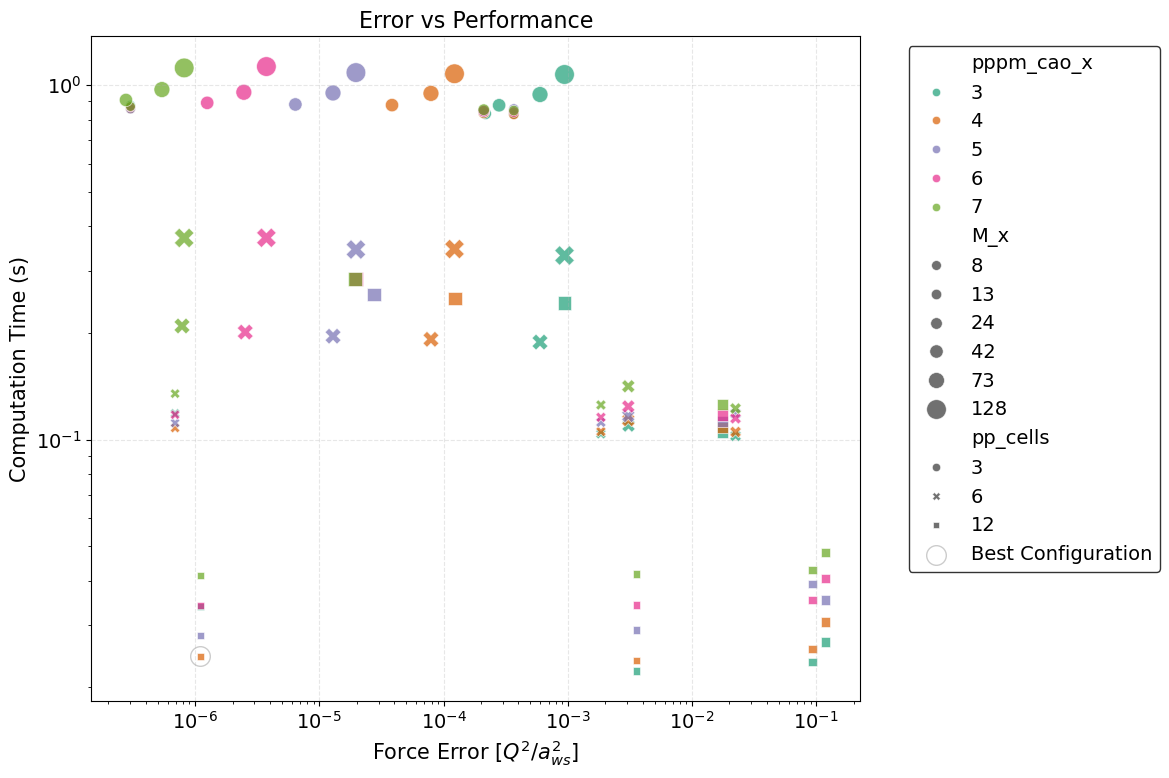

In [5]:
pareto_points, best_point = find_pareto_optimal_configs(preproc, configuration_df, target_error=1e-5)
plot_error_vs_performance(preproc, configuration_df, None, best_point) 

In [ ]:
from sarkas.utilities.maths import force_error_analytic_pp, force_error_approx_pppm, force_error_approx_pm

def analytical_approx_pppm(self, configuration_df=None, best_point=None):
    """Calculate the total force error as given in :cite:`Dharuman2017`."""

    if configuration_df is None:
        configuration_df = self.dataframe
    if best_point is None:
        pareto_points, best_point = find_pareto_optimal_configs(configuration_df=configuration_df)
    if best_point is None:
        raise ValueError("No best point found. Please run the parameter optimization first.")

    # Find the number of cells for the best cutoff radius
    if 'pp_cells' in best_point:
        n_cells = best_point['pp_cells']
    else:
        n_cells = int(self.potential.box_lengths.min() / best_point['r_cut'])

    r_min = self.potential.box_lengths.min() / (n_cells*10)
    r_max = self.potential.box_lengths.min() / (n_cells * 0.51)
    
    # Calculate the minimum and maximum alpha values based on the Ewald parameter
    # Get the best Mesh size from the best point
    if 'M_x' in best_point:
        mesh_size = best_point['M_x']
    else:
        mesh_size = self.potential.pppm_mesh[0]  # Default to first mesh size if not found
    a_min = 0.03*mesh_size / self.potential.box_lengths.min()
    a_max = 0.9*mesh_size / self.potential.box_lengths.min() 

    alphas = np.linspace(a_min, a_max, 101)
    rcuts = np.linspace(r_min, r_max, 101)

    pm_force_error = np.zeros(len(alphas))
    pp_force_error = np.zeros((len(alphas), len(rcuts)))
    total_force_error = np.zeros((len(alphas), len(rcuts)))

    # TODO: Fix this hack
    potential_copy = self.potential.__copy__()
    # Reset the potential parameters
    potential_copy.estimate_parameters = False
    potential_copy.setup(self.parameters, self.species)
    # potential_copy = self.potential.__deepcopy__()
    for ia, alpha in enumerate(alphas):
        for ir, rc in enumerate(rcuts):
            potential_copy.rc = rc
            potential_copy.pppm_alpha_ewald = alpha
            tot_err, pm_err, pp_err = force_error_approx_pppm(potential_copy)
            total_force_error[ia, ir] = tot_err
            pm_force_error[ia] = pm_err
            pp_force_error[ia, ir] = pp_err

    return (
        total_force_error,
        pp_force_error,
        pm_force_error,
        rcuts / potential_copy.a_ws,
        alphas * potential_copy.a_ws,
    )

total_force_error, pp_force_error, pm_force_error, rcuts, alphas = analytical_approx_pppm(preproc, configuration_df=configuration_df, best_point=best_point)
chosen_alpha = best_point["pppm_alpha_ewald"] * preproc.parameters.a_ws
chosen_rcut = best_point["r_cut"] / preproc.parameters.a_ws

# Color Map
preproc.make_pppm_color_map(rcuts, alphas, chosen_alpha, chosen_rcut, total_force_error)

# Line Plot
preproc.make_pppm_line_plot(rcuts, alphas, chosen_alpha, chosen_rcut, total_force_error)


# How to choose the best PPPM parameters?

One of the most time consuming thing when running simulations is to find the optimal parameters for the PPPM algorithm. Very often this search of optimal parameters is a trail-and-error search since we want to run simulations and focus on the physics instead of the computational part. This can lead to inefficient simulations and sometimes leading to wrong results. The goal of this notebook is to improve on the trial-and-error method and find an algorithm to decide the optimal parameters. The goal is to keep the discussion brief and simple such that it is easy to understand and we are able to modify it in the future. 


## Definition of optimal parameters

The first thing we need to decide is what do we mean by optimal parameters, optimal with respect to what? The two most important things we are concerned is accuracy and speed. By accuracy we mean that we want to minimize the force error incurred when applying the PPPM algorithm. By speed we mean that we want to minimize the time it takes to compute the forces between the particles. For the remainder of this notebook we will focus only a cubic box with periodic boundary conditions. 

The parameters of the PPPM methods
* $r_c$ the cutoff radius for the short range part of the calculation
* $\alpha$ the Ewald alpha parameter
* $M_x, M_y, M_z$ the number of mesh points in each direction
* $p_x, p_y, p_z$ the charge assignment order (or support) of the B-spline window function
* $a_x, a_y, a_z$ the number of aliases per cartesian direction. We will neglect this for the remainder of this topic.


### Timing

The time complexity of the algorithm is 

$$ t = a_1 \left ( \frac{4\pi n}{3} r_c^3 \right ) N + \left (a_2 + a_3 p_x p_y p_z \right ) N + M_xM_yM_z \left (a_4 \log(M_xM_yM_z) + a_5 \right ) $$

where $N$ is the number of particles and $a_i$ are prefactors that depend on the computational hardware. As you can see the all the above terms are monotonically increasing with the parameters as such the smallest time is achieved when the parameters are zero. 

### Force error

The force error is divided into two parts; $\Delta F_{\mathcal R}$ the force error due to the short-range part and $\Delta F_{\mathcal F}$ the force error due to the long-range part of the calculation. The total force error is then given by 

$$ \Delta F_{\textrm{tot}} = \sqrt{ \Delta F_{\mathcal R}^2 + \Delta F_{\mathcal F}^2 } $$

where 

$$ \Delta F_{\mathcal R} \simeq 2 Q^2 \sqrt{\frac{N}{V}} \frac{e^{-\alpha^2 r_c^2}}{\sqrt{r_c}} e^{-\kappa^2/4 \alpha^2}$$

and 

$$ \Delta F_{\mathcal F} = \Delta F_{\mathcal F}^{(\textrm{approx})}  \simeq Q^2 \sqrt{\frac{N}{V}} A_{\mathcal F}^{1/2}, $$
$$A_{\mathcal F} \simeq \frac{3}{2\pi^2} \sum_{m = 0}^{p -1 } C_{m}^{(p)} \left ( \frac{h}2 \right )^{2 (p + m)} \frac{2}{1 + 2(p + m)} \beta(p,m), $$
$$ \beta(p,m)  = \int_0^{\infty} dk \; G_k^2 k^{2(p + m + 2)}, \quad G_k = \frac{4\pi}{k^2 + \kappa^2} e^{-(k^2 + \kappa^2)/(4 \alpha^2)}$$

where we assumed the potential to be Yukawa and $h = L_x/M_x$ and the coefficients $C_m^{(p)}$ are listed in Table I of :cite:`Deserno1998`. The functions :func:`sarkas.utilities.maths.force_error_analytic_pp` and :func:`sarkas.utilities.maths.force_error_approx_pm` calculate $\Delta F_{\mathcal R}$ and $\Delta F_{\mathcal F}$ respectively. 

In the code below, we calculate the $\Delta F_{\mathcal R}$ and $\Delta F_{\mathcal F}$ for a set of values of $\alpha$ and $M = M_x = M_y = M_z$ at fixed $r_c$ and $p = p_x = p_y = p_z$. 



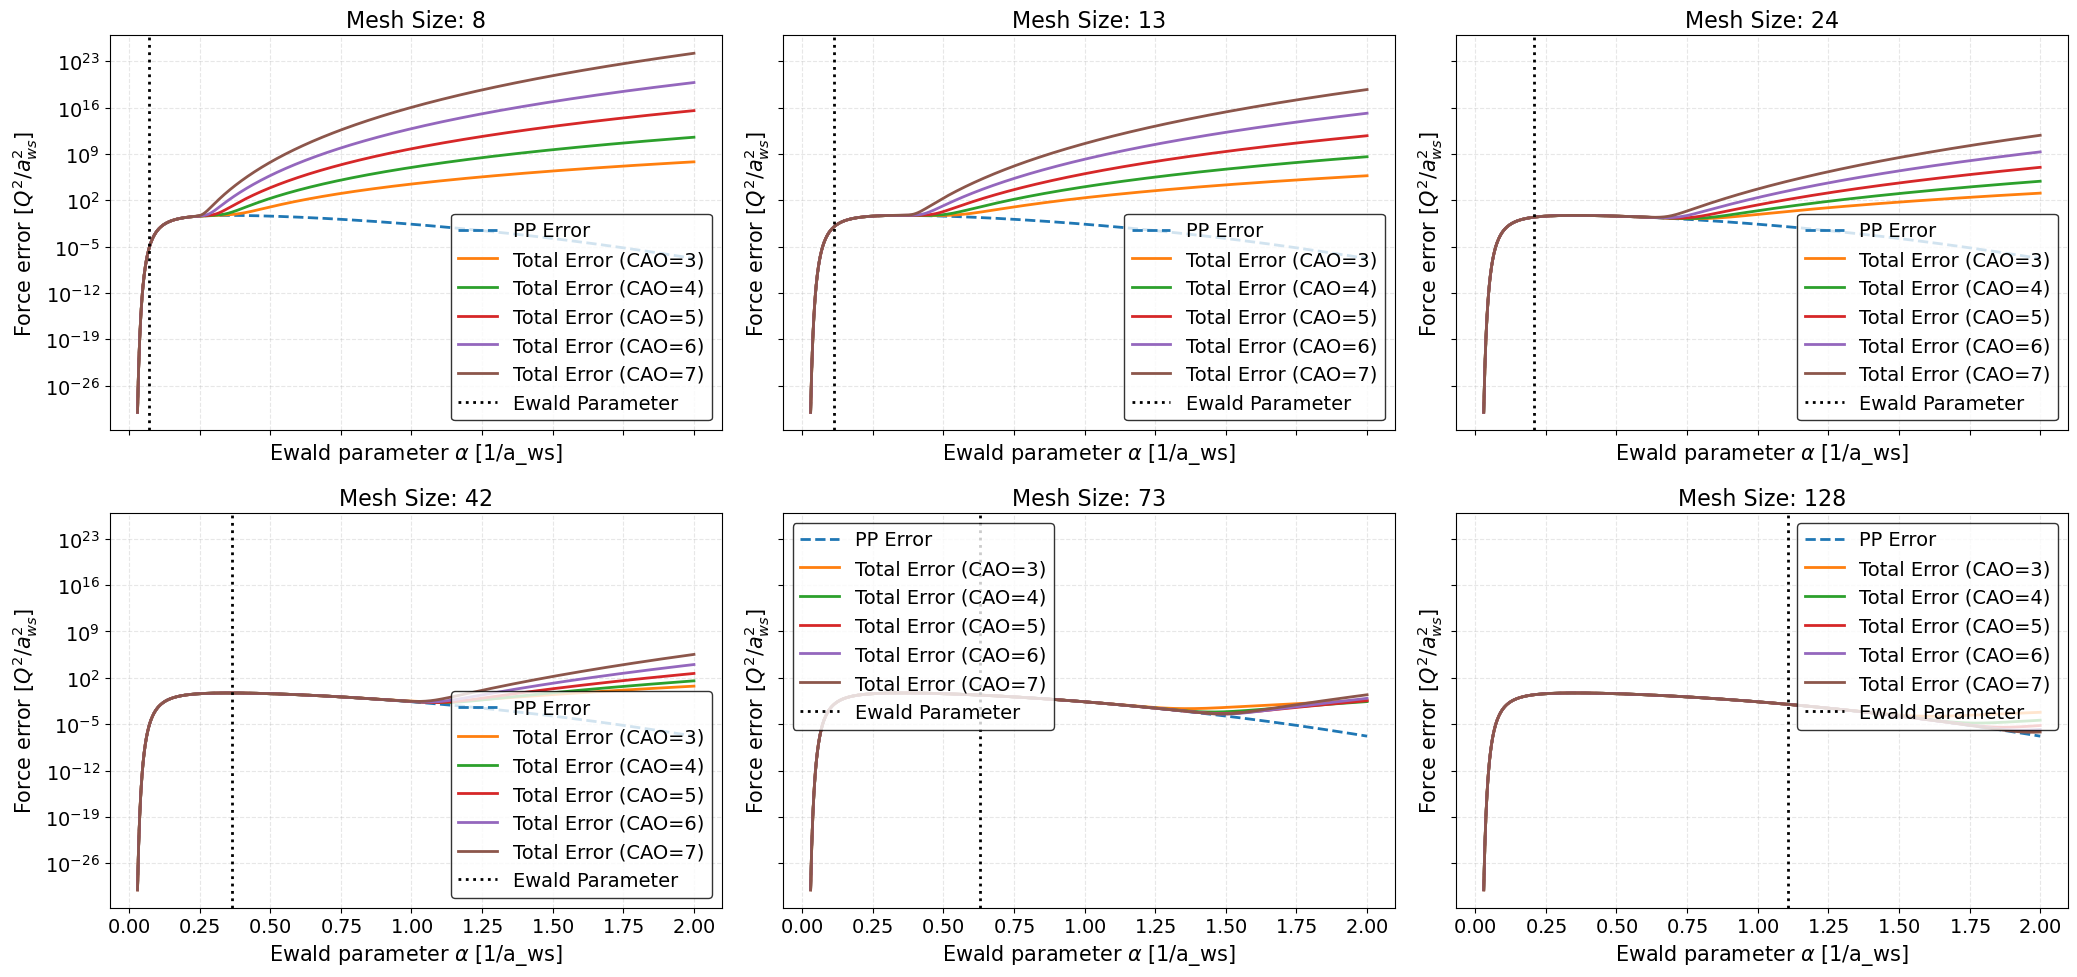

In [6]:
rc = 2 # Cutoff radius in units of a_ws
alphas = np.linspace(0.03, 2, 1000) 
h = preproc.potential.box_lengths.min()/ 64 / preproc.parameters.a_ws  # Assuming a mesh size of 64 for the h parameter

cols = len(pm_meshes) // 2
rows = 2
figsize = (21, 10)
fig, axes = plt.subplots(rows, cols, figsize = figsize, sharex=True, sharey=True)

fpm = np.zeros(len(alphas))
fpp = force_error_analytic_pp("yukawa", rc, 0.5, alphas, 1.0)
f_tot = fpp + fpm
for iax, ax in enumerate(axes.flat):
    ax.plot(alphas, fpp, label='PP Error', linestyle='--')
    m = pm_meshes[iax]
    h = preproc.potential.box_lengths.min() / m / preproc.parameters.a_ws
    for j, c in enumerate(pm_caos):
        fpm = force_error_approx_pm(0.5, c, h, alphas, 1.0)**2
        f_tot = fpp + fpm
        # ax.plot(alphas, fpm[:], label=f'PM Error (CAO={c})', linestyle='-')
        ax.plot(alphas, f_tot, linestyle='-', label=f'Total Error (CAO={c})')
    ax.axvline(0.3/ h, color='k', linestyle=':', label='Ewald Parameter')
    ax.set_title(f'Mesh Size: {pm_meshes[iax]}')
    ax.set_yscale('log')
    ax.set_xlabel(r'Ewald parameter $\alpha$ [1/a_ws]')
    ax.set_ylabel(r'Force error $[Q^2/a_{ws}^2]$')
    ax.legend()
plt.tight_layout() 

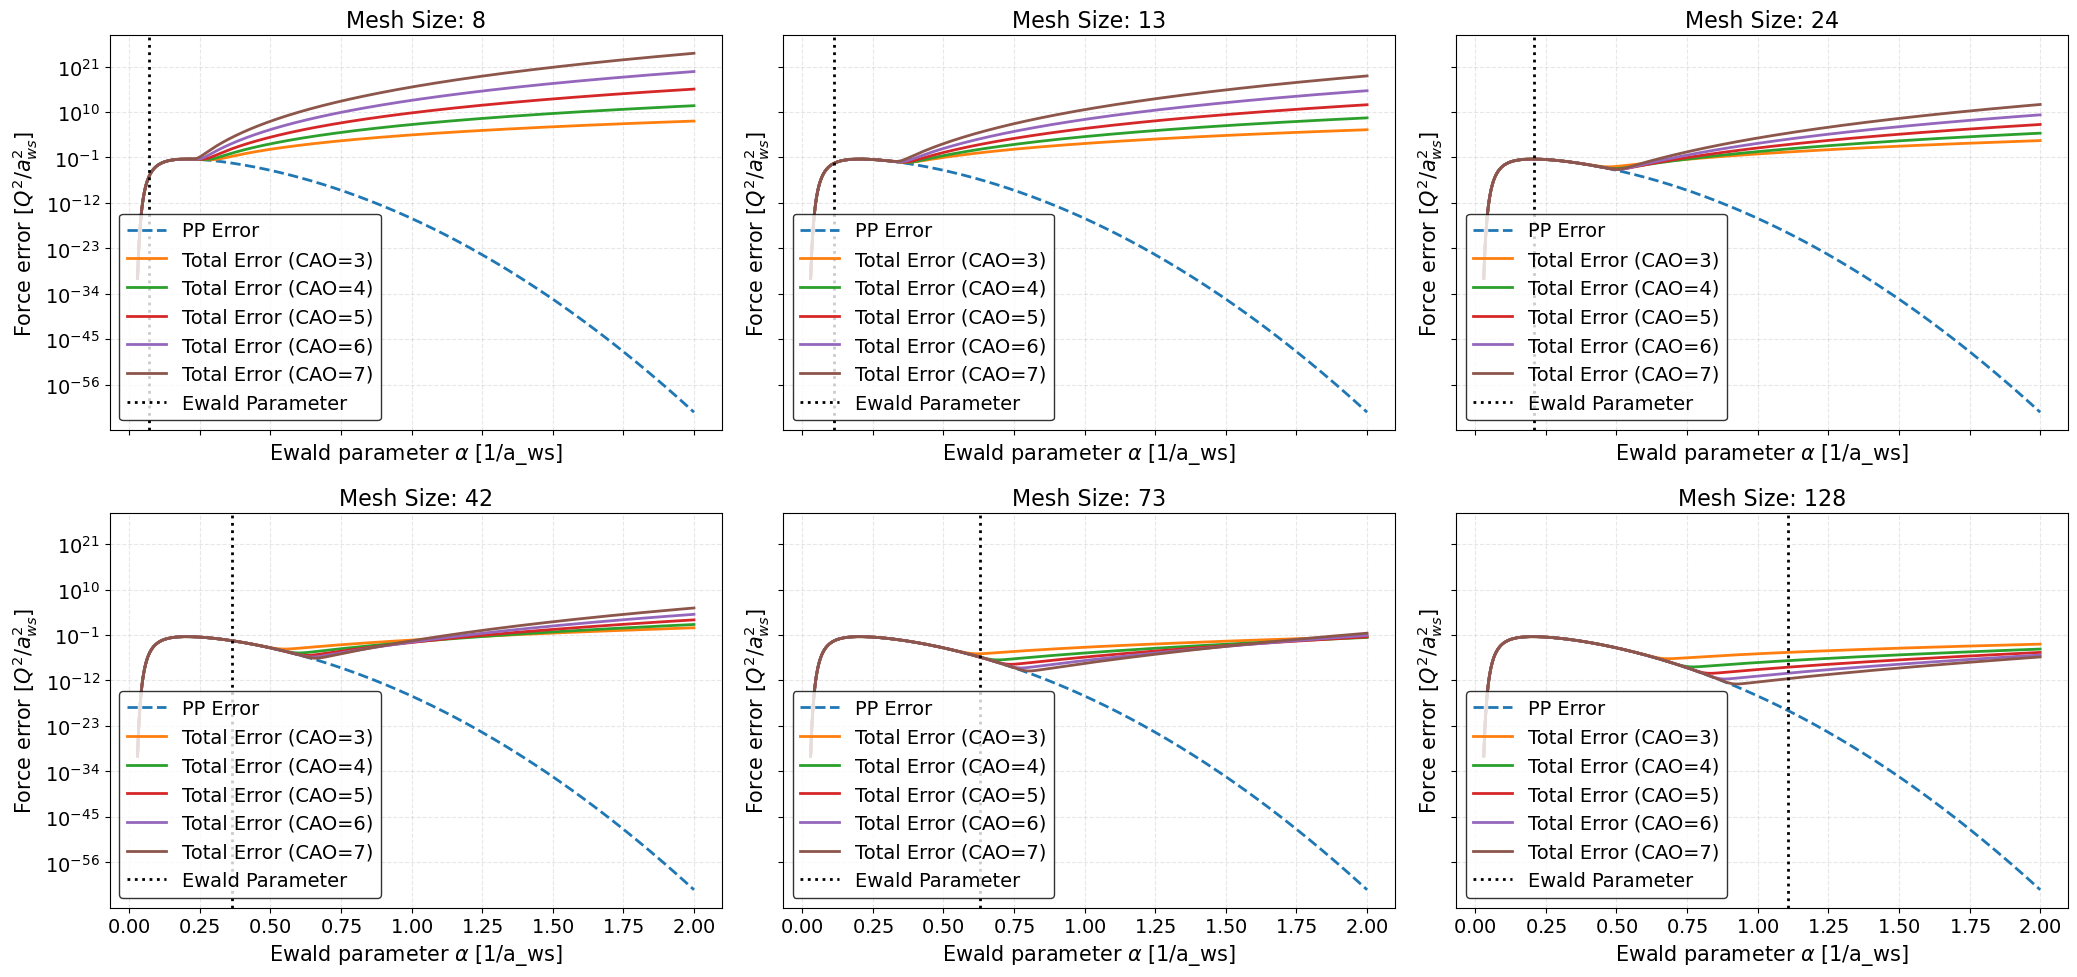

In [7]:
# Increase rc to 6

rc = 6 # Cutoff radius in units of a_ws
alphas = np.linspace(0.03, 2, 1000) 
h = preproc.potential.box_lengths.min()/ 64 / preproc.parameters.a_ws  # Assuming a mesh size of 64 for the h parameter

cols = len(pm_meshes) // 2
rows = 2
figsize = (21, 10)
fig, axes = plt.subplots(rows, cols, figsize = figsize, sharex=True, sharey=True)

fpm = np.zeros(len(alphas))
fpp = force_error_analytic_pp("yukawa", rc, 0.5, alphas, 1.0)
f_tot = fpp + fpm
for iax, ax in enumerate(axes.flat):
    ax.plot(alphas, fpp, label='PP Error', linestyle='--')
    m = pm_meshes[iax]
    h = preproc.potential.box_lengths.min() / m / preproc.parameters.a_ws
    for j, c in enumerate(pm_caos):
        fpm = force_error_approx_pm(0.5, c, h, alphas, 1.0)**2
        f_tot = fpp + fpm
        # ax.plot(alphas, fpm[:], label=f'PM Error (CAO={c})', linestyle='-')
        ax.plot(alphas, f_tot, linestyle='-', label=f'Total Error (CAO={c})')
    ax.axvline(0.3/ h, color='k', linestyle=':', label='Ewald Parameter')
    ax.set_title(f'Mesh Size: {pm_meshes[iax]}')
    ax.set_yscale('log')
    ax.set_xlabel(r'Ewald parameter $\alpha$ [1/a_ws]')
    ax.set_ylabel(r'Force error $[Q^2/a_{ws}^2]$')
    ax.legend()
plt.tight_layout() 

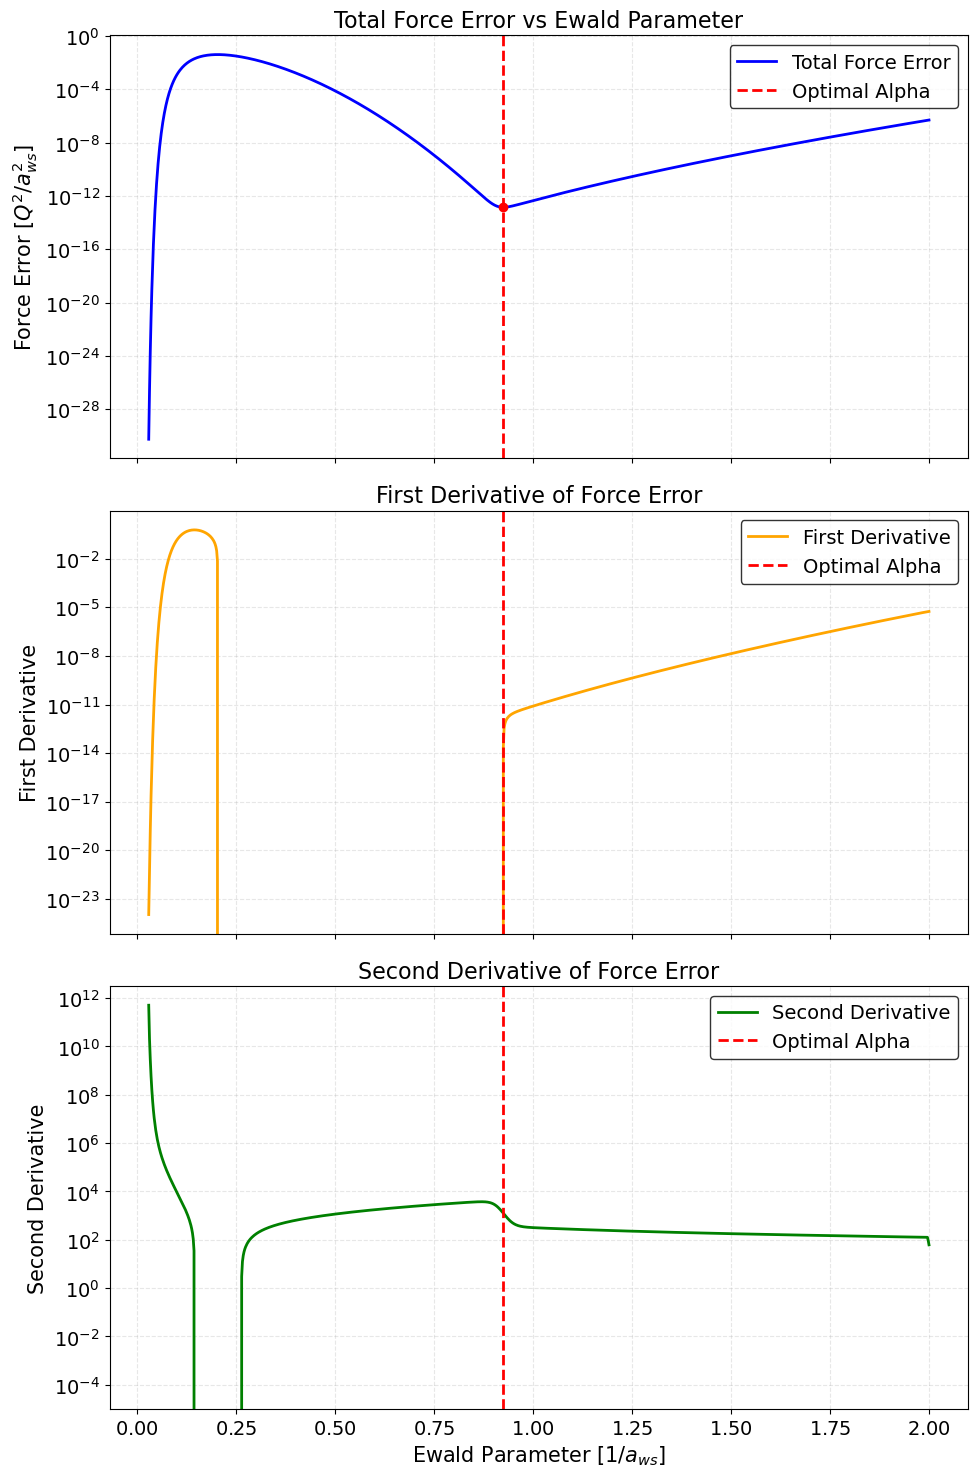

In [14]:
# Calculate the first and second derivative of the force error with respect to the Ewald parameter
def calculate_derivatives(alphas, force_error):
    """
    Calculate the first and second derivatives of the force error with respect to the Ewald parameter.
    
    Parameters
    ----------
    alphas : numpy.ndarray
        Array of Ewald parameters.
    force_error : numpy.ndarray
        Array of force errors corresponding to the Ewald parameters.
    
    Returns
    -------
    tuple
        First and second derivatives of the force error.
    """
    first_derivative = np.gradient(force_error, alphas)
    second_derivative = np.gradient(first_derivative, alphas)
    
    return first_derivative, second_derivative

# Calculate the derivatives for the total force error
first_derivative, second_derivative = calculate_derivatives(alphas, f_tot)
# Find the minimum of the total force error for alpha > 0.5
min_index = np.argmin(f_tot[alphas > 0.5])
# Get the optimal alpha value and corresponding force error
optimal_alpha = alphas[alphas > 0.5][min_index]
optimal_force_error = f_tot[alphas > 0.5][min_index]

# Plot the function and its first and second derivatives
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
axes[0].plot(alphas, f_tot, label='Total Force Error', color='blue')
axes[0].axvline(optimal_alpha, color='red', linestyle='--', label='Optimal Alpha')
axes[0].scatter(optimal_alpha, optimal_force_error, color='red', zorder=5)
axes[0].set_title('Total Force Error vs Ewald Parameter')
axes[0].set_ylabel(r'Force Error [$Q^2/a_{ws}^2$]')
axes[0].set_yscale('log')
axes[0].legend()

axes[1].plot(alphas, first_derivative, label='First Derivative', color='orange')
axes[1].axvline(optimal_alpha, color='red', linestyle='--', label='Optimal Alpha')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('First Derivative of Force Error')
axes[1].set_ylabel('First Derivative')
axes[1].legend()

axes[2].plot(alphas, second_derivative/f_tot, label='Second Derivative', color='green')
axes[2].axvline(optimal_alpha, color='red', linestyle='--', label='Optimal Alpha')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('Second Derivative of Force Error')
axes[2].set_xlabel(r'Ewald Parameter [$1/a_{ws}$]')
axes[2].set_ylabel('Second Derivative')
axes[2].legend()

for a in axes[1:]:
    a.set_yscale('log')
plt.tight_layout()

The plots show that $\Delta F_{\mathcal R}$ is larger than $\Delta F_{\mathcal F}$ up to a certain value of $\alpha$. The minimum of the force error is when the two terms are equal. In addition, we notice that the larger $p$ CAOs lead to a smaller $\Delta F_{\mathcal F}$ only up to a certain value of $\alpha$. For small mesh sizes $M$ the cross over happens after the crossing of the two force errors. 

Let's know write the code for finding the optimal parameters by minimizing the force error starting from a threshold. We further impose the condition that the PM force error should be equal to the PP force error and both should not be zero. 

In [15]:
from matplotlib.colors import LogNorm
from numpy import array, isclose
from numpy.typing import NDArray, ArrayLike
from scipy.optimize import minimize, differential_evolution
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional
from sarkas.utilities.maths import force_error_approx_pm, force_error_analytic_pp
from pandas import DataFrame

class PPPMOptimizer:
    """
    Optimizer for PPPM (Particle-Particle Particle-Mesh) algorithm parameters.
    
    Finds optimal parameters (alpha, rc, M, cao) such that the short-range and 
    long-range force errors are equal and below a specified threshold.
    """
    
    def __init__(self, N: int, V: float, L: float, Q: float = 1.0, kappa: float = 0.5, 
                 potential_type: str = "yukawa"):
        """
        Initialize the optimizer with system parameters.
        
        Parameters:
        -----------
        N : int
            Number of particles
        V : float
            Volume of the simulation box
        L : float
            Box length (assuming cubic box)
        Q : float
            Charge magnitude (default: 1.0)
        kappa : float
            Yukawa screening parameter (default: 0.5)
        potential_type : str
            Type of potential (default: "yukawa")
        """
        self.N = N
        self.V = V
        self.L = L
        self.Q = Q
        self.kappa = kappa
        self.potential_type = potential_type
        self.rc_range = (2.0, self.L/2.0)
        self.alpha_range = (1e-5, 10)
        self.total_force_error_threshold = 1e-5  # Default threshold for total force error

    def force_error_pp(self, rc: float, alpha: float) -> float:
        """
        Calculate the short-range (PP) force error using sarkas utilities.
        
        Parameters:
        -----------
        rc : float
            Cutoff radius
        alpha : float
            Ewald parameter
            
        Returns:
        --------
        float
            Short-range force error
        """

        base_error = force_error_analytic_pp(self.potential_type, rc, self.kappa, alpha, sqrt(3.0/ (4.0 * np.pi)) )
        return base_error
    
    
    def force_error_pm(self, M: int, cao: int, alpha: float) -> float:
        """
        Calculate the long-range (PM) force error using sarkas utilities.
        
        Parameters:
        -----------
        M : int
            Number of mesh points per dimension
        cao : int
            Charge assignment order
        alpha : float
            Ewald parameter
            
        Returns:
        --------
        float
            Long-range force error
        """
        h = self.L / M  # mesh spacing
        
        # base_error = force_error_approx_pm_vectorized(self.kappa, cao, h, alpha, self.Q)
        base_error = force_error_approx_pm(self.kappa, cao, h, alpha, sqrt(3.0/ (4.0 * np.pi)))
        return base_error
    
    def total_force_error(self, rc: float, alpha: float, M: int, cao: int) -> float:
        """Calculate total force error."""
        delta_F_R = self.force_error_pp(rc, alpha)
        delta_F_F = self.force_error_pm(M, cao, alpha)
        return np.sqrt(delta_F_R**2 + delta_F_F**2)
    
    def error_difference(self, rc: float, alpha: float, M: int, cao: int) -> float:
        """Calculate the difference between PP and PM errors."""
        delta_F_R = self.force_error_pp(rc, alpha)
        delta_F_F = self.force_error_pm(M, cao, alpha)
        return abs(delta_F_R - delta_F_F)
    
    def _calculate_error_balance(self, rc: float, alpha: float, M: int, cao: int) -> Tuple[float, float, float, float]:
        """
        Calculate PP error, PM error, total error, and error balance for given parameters.
        
        Returns:
        --------
        tuple
            (pp_error, pm_error, total_error, error_balance)
        """
        try:
            pp_error = self.force_error_pp(rc, alpha)
            pm_error = self.force_error_pm(M, cao, alpha)
            total_error = np.sqrt(pp_error**2 + pm_error**2)
            error_balance = abs(pp_error - pm_error)
            return pp_error, pm_error, total_error, error_balance
        except:
            return np.inf, np.inf, np.inf, np.inf
    
    def is_valid_solution(self,
                            M: int, alpha: float, rc: float, cao: int,
                            tolerance: float = 1e-12,
                            total_force_error_threshold: Optional[float] = None) -> Tuple[bool, float, float, float]:
        """
        Check if the solution is valid based on the force errors and ratio.
        Parameters:
        -----------
        M : int
            Number of mesh points per dimension
        alpha : float
            Ewald parameter
        rc : float
            Cutoff radius
        cao : int
            Charge assignment order
        tolerance : float
            Tolerance for equality of PP and PM errors
        total_force_error_threshold : float, optional
            Maximum allowed total force error. If None, uses the class default.
        Returns:
        --------
        Tuple[bool, float, float, float]
            (is_valid, pp_error, pm_error, ratio)
            is_valid: True if solution is valid, False otherwise
            pp_error: Short-range force error
            pm_error: Long-range force error
            ratio: Ratio of PP to PM error
        """
        if total_force_error_threshold is None:
            try:
                pp_error, pm_error, total_error, error_balance = self._calculate_error_balance(rc, alpha, M, cao)
                
                if total_error <= self.total_force_error_threshold and pp_error > 0 and pm_error > 0:
                    ratio = pp_error / pm_error if pm_error != 0 else float('inf')
                    is_valid = isclose(ratio, 1.0, atol=tolerance)
                    return is_valid, pp_error, pm_error, ratio
                else:
                    return False, pp_error, pm_error, float('nan')
                                
            except:
                return False, None, None, None
        else:
            # Use total force error threshold
            pp_error, pm_error, total_error, error_balance = self._calculate_error_balance(rc, alpha, M, cao)
            
            if total_error <= total_force_error_threshold and pp_error > 0 and pm_error > 0:
                ratio = pp_error / pm_error if pm_error != 0 else float('inf')
                is_valid = error_balance < tolerance
                return is_valid, pp_error, pm_error, ratio
            else:
                return False, pp_error, pm_error, float('nan')
            

    def objective_function(self, params, cao):
        """
        Objective function to minimize: |pp_error - pm_error| with additional constraint
        that both errors must be non-negligible for a valid solution.
        
        Parameters:
        - params: [M, alpha, rc] (M will be rounded to nearest integer)
        - cao: fixed cao value for this optimization
        """
        M, alpha, rc = params
        M = int(round(M))  # Ensure M is integer
        
        # Ensure M is positive
        if M <= 0:
            return 1e10
        
        try:
            pp_error, pm_error, total_error, error_balance = self._calculate_error_balance(rc, alpha, M, cao)
            
            # Check if both errors are too small (avoid trivial solutions)
            min_error_threshold = 1e-12
            if abs(pp_error) < min_error_threshold and abs(pm_error) < min_error_threshold:
                return 1e10  # Reject trivial solutions where both are ~0
            
            # If one error is zero but the other isn't, that's not a valid solution
            if abs(pp_error) < min_error_threshold or abs(pm_error) < min_error_threshold:
                if error_balance > min_error_threshold:
                    return 1e10
            
            if total_error > self.total_force_error_threshold:
                return 1e10
            
            return error_balance
        except:
            return 1e10
    
    # def _optimize_continuous_params(self, M: int, cao: int, error_threshold: float,
    #                                rc_range: Tuple[float, float], 
    #                                alpha_range: Tuple[float, float]) -> Optional[Dict]:
    #     """
    #     Optimize continuous parameters (rc, alpha) for fixed discrete parameters (M, cao).
        
    #     Returns:
    #     --------
    #     dict or None
    #         Optimization result with parameters and errors, or None if optimization fails
    #     """
    #     def objective_function(params):
    #         rc, alpha = params
    #         pp_error, pm_error, total_error, error_balance = self._calculate_error_balance(rc, alpha, M, cao)
            
    #         # Penalty if above threshold or invalid errors
    #         if total_error > error_threshold or pp_error <= 0 or pm_error <= 0:
    #             return 1e10 + total_error
            
    #         # Minimize the imbalance between PP and PM errors
    #         return error_balance
        
    #     # Initial guess at center of ranges
    #     initial_guess = [np.mean(rc_range), np.mean(alpha_range)]
    #     bounds = [rc_range, alpha_range]
        
    #     try:
    #         optimization_result = minimize(
    #             objective_function, 
    #             initial_guess, 
    #             bounds=bounds, 
    #             method='L-BFGS-B'
    #         )
            
    #         if not optimization_result.success:
    #             return None
                
    #         rc_opt, alpha_opt = optimization_result.x
    #         pp_error, pm_error, total_error, error_balance = self._calculate_error_balance(
    #             rc_opt, alpha_opt, M, cao
    #         )
            
    #         # Verify the solution meets our criteria
    #         if total_error <= error_threshold and pp_error > 0 and pm_error > 0:
    #             return {
    #                 'rc': rc_opt,
    #                 'alpha': alpha_opt,
    #                 'M': M,
    #                 'cao': cao,
    #                 'pp_error': pp_error,
    #                 'pm_error': pm_error,
    #                 'total_error': total_error,
    #                 'error_balance': error_balance,
    #                 'pp_pm_ratio': pp_error / pm_error
    #             }
    #         else:
    #             return None
                
    #     except Exception:
    #         return None

    def solve_optimization(self,
                            method: str = 'differential_evolution',
                            tolerance: float = 1e-12,
                            num_trials: int = 10) -> DataFrame:
        """
        Solve the optimization problem to find valid PPPM parameters.
        Parameters:
        -----------
        method : str
            Optimization method to use ('differential_evolution' or 'minimize').
        tolerance : float
            Tolerance for equality of PP and PM errors.
        num_trials : int
            Number of trials for 'minimize' method to avoid local minima.
        Returns:
        --------
        DataFrame
            DataFrame containing valid solutions with parameters and errors.
        """
        
        bounds = [
            (max(8, self.M_range[0]), self.M_range[1]),  # M bounds
            (self.alpha_range[0], self.alpha_range[1]),   # alpha bounds
            (self.rc_range[0], self.rc_range[1])          # rc bounds
        ]
        
        valid_solutions = []
        
        for cao in self.cao_options:
            if method == 'differential_evolution':
                # Global optimization
                result = differential_evolution(
                    lambda params: self.objective_function(params, cao),
                    bounds,
                    maxiter=2000,
                    tol=1e-12,
                    atol=1e-12
                )
                
                if result.success:
                    M, alpha, rc = result.x
                    M = int(round(M))
                    is_valid, pp_error, pm_error, ratio = self.is_valid_solution(M, alpha, rc, cao, tolerance)
                    
                    if is_valid:
                        valid_solutions.append({
                            'M': M,
                            'alpha': alpha,
                            'rc': rc,
                            'cao': cao,
                            'pp_error': pp_error,
                            'pm_error': pm_error,
                            'tot_error': np.sqrt(pp_error**2 + pm_error**2),
                            'error_diff': abs(pp_error - pm_error),
                            'ratio': ratio,
                            'valid': is_valid
                        })
            
            elif method == 'minimize':
                # # Multiple random starting points
                for _ in range(num_trials):
                    # Random starting point
                    x0 = [
                        np.random.uniform(bounds[0][0], bounds[0][1]),
                        np.random.uniform(bounds[1][0], bounds[1][1]),
                        np.random.uniform(bounds[2][0], bounds[2][1])
                    ]
                    
                    result = minimize(
                        lambda params: self.objective_function(params, cao),
                        x0,
                        bounds=bounds,
                        method='L-BFGS-B',
                        options={'ftol': 1e-12, 'gtol': 1e-12}
                    )
                    
                    if result.success:
                        M, alpha, rc = result.x
                        M = int(round(M))
                        is_valid, pp_error, pm_error, ratio = self.is_valid_solution(M, alpha, rc, cao, tolerance)
                        
                        if is_valid:
                            # Check if this solution is already found
                            is_duplicate = False
                            for sol in valid_solutions:
                                if (sol['cao'] == cao and 
                                    isclose(sol['M'],M) and
                                    isclose(sol['alpha'],alpha, rtol = 1e-6) and
                                    isclose(sol['rc'],rc ,rtol = 1e-6) ):
                                    is_duplicate = True
                                    break
                            
                            if not is_duplicate:
                                valid_solutions.append({
                                    'M': M,
                                    'alpha': alpha,
                                    'rc': rc,
                                    'cao': cao,
                                    'pp_error': pp_error,
                                    'pm_error': pm_error,
                                    'tot_error': np.sqrt(pp_error**2 + pm_error**2),
                                    'error_diff': abs(pp_error - pm_error),
                                    'ratio': ratio,
                                    'valid': is_valid
                                })
            
        return DataFrame(valid_solutions)
    
    # def find_optimal_parameters(self, error_threshold: float,
    #                           rc_range: Tuple[float, float],
    #                           alpha_range: Tuple[float, float],
    #                           M_range: Tuple[float, float],
    #                         #   M_options: list,
    #                           cao_options: list) -> Dict:
    #     """
    #     Find optimal PPPM parameters (rc, alpha, M, cao) where PP and PM errors are equal
    #     and total error is below threshold.
        
    #     Parameters:
    #     -----------
    #     error_threshold : float
    #         Maximum allowed total force error.
    #     rc_range : tuple
    #         Range for cutoff radius optimization.
    #     alpha_range : tuple
    #         Range for Ewald parameter optimization.
    #     M_options : list
    #         List of mesh sizes to test.
    #     cao_options : list
    #         List of CAO values to test.
            
    #     Returns:
    #     --------
    #     dict or None
    #         Dictionary with optimal parameters and errors, or None if no solution found
    #     """
    #     best_result = None
    #     best_balance = np.inf
    #     best_total_error = np.inf
        
    #     # Iterate over all cao options
    #     for cao in cao_options:
    #         # Optimize continuous parameters for this discrete combination
    #         result = self._optimize_continuous_params(
    #             M, cao, error_threshold, rc_range, alpha_range
    #         )
            
    #         if result is None:
    #             continue
            
    #         # Check if this is better than previous best
    #         error_balance = result['error_balance']
    #         total_error = result['total_error']
            
    #         is_better = (
    #             error_balance < best_balance or 
    #             (error_balance < 2 * best_balance and total_error < best_total_error)
    #         )
            
    #         if is_better:
    #             best_balance = error_balance
    #             best_total_error = total_error
    #             best_result = result
        
    #     return best_result
    
    def optimize_parameters(self,
                            tot_force_error_threshold: Optional[float] = None,
                          rc_range: Optional[Tuple[float, float]] = None,
                          alpha_range: Tuple[float, float] = None,
                            M_range: Optional[Tuple[float, float]] = None,
                            M_options: Optional[list] = None,
                            cao_options: Optional[list] = [3, 4, 5, 6, 7],
                            optimization_method: str = 'differential_evolution',
                            num_trials: int = 10,
                            tolerance: float = 1e-12
                          ) -> Dict:
        """
        Find optimal PPPM parameters for given error threshold.
        
        This method now uses the comprehensive parameter optimization with proper ranges.
        
        Parameters:
        -----------
        tot_force_error_threshold : float, optional
            Maximum allowed total force error (default: 1e-5)
        rc_range : tuple, optional
            Range for cutoff radius search (default: (0.5, L/2))
        alpha_range : tuple, optional
            Range for Ewald parameter search. Default: (2.0/L, 200.0/L)
        M_range : tuple, list or array
            Range for mesh size search
        M_options : list, optional
            List of mesh sizes to test. If provided, overrides M_range.
        cao_options : list
            Charge assignment orders to test. Default: [3, 4, 5, 6, 7]
            
        Returns:
        --------
        dict
            Dictionary with optimal parameters and errors
        """

        if tot_force_error_threshold is not None:
            self.total_force_error_threshold = tot_force_error_threshold

        # Set default rc_range if not provided or if upper bound is None
        if rc_range is None:
            rc_range = self.rc_range
        elif isinstance(rc_range, tuple) and len(rc_range) == 2 and rc_range[1] is None:
            rc_range = (rc_range[0], self.L/2)
            self.rc_range = rc_range  # Store for later use
        elif not isinstance(rc_range, (tuple, list, np.ndarray)) or (isinstance(rc_range, tuple) and len(rc_range) != 2):
            raise ValueError("rc_range must be tuple of length 2, list or array")

        # Set default alpha_range if not provided
        if alpha_range is None:
            alpha_range = self.alpha_range
        elif isinstance(alpha_range, tuple) and len(alpha_range) == 2:
            if alpha_range[1] is None:
                self.alpha_range = (alpha_range[0], 200.0 / self.L)
        else:
            raise ValueError("alpha_range must be tuple of length 2")

        # Handle M_range input
        if isinstance(M_range, tuple):
            if len(M_range) != 2:
                raise ValueError("If M_range is tuple, it must have length 2")
            self.M_range = [M_range[0], M_range[1]]  # Convert to list for consistency
        elif M_options is not None:
            if not isinstance(M_options, (list, NDArray)):
                raise ValueError("M_options must be list or array")
            # Check that M_options is a list of integers
            if not all(isinstance(m, int) and m > 0 for m in M_options):
                raise ValueError("M_options must contain only positive integers")
            self.M_options = array(M_options, dtype=int)
            self.M_range = (min(M_options), max(M_options))
        else: # Both M_range and M_options are None
            self.M_range = (8, 128)  # Default range for mesh sizes
            self.M_options = array([2**i for i in range(3, 8)])  # Default mesh sizes from 8 to 128
            
        # Validate cao_options
        if not isinstance(cao_options, (list, NDArray)):
            raise ValueError("cao_options must be list or array")

        # Convert to an array of integers for consistency
        self.cao_options = array(cao_options, dtype=int)

        # Use the comprehensive optimization
        valid_solutions_df = self.solve_optimization( method=optimization_method,
                                                      tolerance=tolerance,
                                                      num_trials=num_trials)
        
        if valid_solutions_df.empty:
            raise ValueError("No valid solutions found within the specified ranges and error threshold.")            
        
        self.valid_solutions_df = valid_solutions_df  # Store for later use

        # Find the best solution based on the largest total error from the valid solutions
        best_solution = self.valid_solutions_df[ self.valid_solutions_df['valid'] ].sort_values(by='tot_error', ascending=False).iloc[0]
        # Return a dict rather than a df row
        best_params = {
            'M': int(best_solution['M']),
            'alpha': best_solution['alpha'],
            'rc': best_solution['rc'],
            'cao': int(best_solution['cao']),
            'pp_error': best_solution['pp_error'],
            'pm_error': best_solution['pm_error'],
            'total_error': best_solution['tot_error'],
            'error_diff': best_solution['error_diff'],
            'ratio': best_solution['ratio']
        }
        self.best_params = best_params  # Store for later use

        return best_params
    
    def plot_error_surface(self, rc: float, alpha: float, M: int, cao: int,
                           rc_range: Optional[Tuple[float, float]]= None,
                          alpha_range: Tuple[float, float] = None) -> None:
        """Plot PP and PM errors vs alpha for given parameters.
        
        Parameters:
        -----------
        rc : float
            Cutoff radius in units of a_ws
        alpha : float
            Ewald parameter in units of 1/a_ws
        M : int
            Number of mesh points per dimension
        cao : int
            Charge assignment order
        rc_range : tuple, optional
            Range for cutoff radius 
        alpha_range : tuple
            Range for Ewald parameter. 
        
        """

        if rc_range is None:
            rc_range = self.rc_range
        if alpha_range is None:
            alpha_range = self.alpha_range

        alphas = np.linspace(alpha_range[0], alpha_range[1], 100)
        rcuts = np.linspace(rc_range[0], rc_range[1], 100)
        r_mesh, a_mesh = meshgrid(rcuts, alphas)

        pp_errors = np.zeros_like(a_mesh)
        pm_errors = np.zeros_like(a_mesh)

        pp_errors = self.force_error_pp(r_mesh, a_mesh)
        pm_errors = self.force_error_pm(M, cao, a_mesh)
        
        total_force_errors = np.sqrt(pp_errors**2 + pm_errors**2)

        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
        CS = ax.pcolormesh(a_mesh, r_mesh, total_force_errors, shading="auto", norm=LogNorm())
        CS2 = ax.contour(a_mesh, r_mesh, total_force_errors, levels=10, colors="w", norm=LogNorm())
        ax.clabel(CS2, fmt="%1.0e", colors="w")
        ax.scatter(alpha, rc, s=200, c="k")
        ax.set_xlabel(r"$\alpha \;a_{ws}$")
        ax.set_ylabel(r"$r_c/a_{ws}$")
        ax.set_title(
            r"Parameters  $N = {}, \quad M = {}, \quad p = {}, \quad \kappa = {:.2f}$".format(
                self.N,
                M,
                cao,
                self.kappa,
            )
        )
        clb = fig.colorbar(CS)
        clb.set_label(r"$\Delta F^{approx}_{tot}(r_c,\alpha)$", va="bottom", rotation=270)
        fig.tight_layout()


In [ ]:
N = 10000
V = preproc.parameters.box_volume/ preproc.parameters.a_ws**3
L = preproc.parameters.box_lengths.min() / preproc.parameters.a_ws
Q = 1.0  # Charge magnitude
kappa = 0.5

# Create optimizer instance - now uses proper ranges and coding practices
optimizer = PPPMOptimizer(N=N, V=V, L=L, Q=Q, kappa=kappa, potential_type="yukawa")

# Find optimal parameters for a given error threshold
error_threshold = 1e-5  # Your desired maximum total force error

print("=== COMPREHENSIVE PARAMETER OPTIMIZATION ===")
print("Optimizing ALL parameters (rc, alpha, M, cao) simultaneously...")
print(f"System parameters: N={N}, V={V:.4e}, L={L:.4e}")
print(f"Default rc range: {optimizer.rc_range[0]:.4e}, {optimizer.rc_range[1]:.4e})")
print(f"Default alpha range: ({optimizer.alpha_range[0]:.4e}, {optimizer.alpha_range[1]:.4e})")
# NEW: Comprehensive optimization with proper ranges
optimizer.alpha_range = (1.0e-5, 2)
optimal_result = optimizer.optimize_parameters(
    tot_force_error_threshold=error_threshold,
    M_range=(15, 65),  # Default range for mesh sizes
    optimization_method='minimize', 
    num_trials=50,  # Increase trials for better exploration
    tolerance=1e-12
    )


if optimal_result:
    print(f"\n✓ Optimal parameters found:")
    print(f"  rc (cutoff radius): {optimal_result['rc']:.4f}")
    print(f"  α (Ewald parameter): {optimal_result['alpha']:.4f}")
    print(f"  M (mesh size): {optimal_result['M']}")
    print(f"  CAO: {optimal_result['cao']}")
    print(f"  rc α = {optimal_result['rc'] * optimal_result['alpha']:.4f} (should be ~ 4)")
    print(f"\n  Force errors:")
    print(f"    ΔF_R (PP): {optimal_result['pp_error']:.2e}")
    print(f"    ΔF_F (PM): {optimal_result['pm_error']:.2e}")
    print(f"    Total: {optimal_result['total_error']:.2e}")
    print(f"    Error balance: {optimal_result['error_diff']:.2e}")
    print(f"    PP/PM ratio: {optimal_result['ratio']:.3f} (ideal = 1.0)")
    
    # Verify conditions
    meets_threshold = optimal_result['total_error'] <= error_threshold
    print(f"    Meets threshold ({error_threshold:.0e})? {meets_threshold}")
    
    # Check if parameters are within expected physical ranges
    print(f"\n  Parameter validation:")
    print(f"    rc < L/2? {optimal_result['rc'] < L/2} ({optimal_result['rc']:.3f} < {L/2:.1f})")
    
    # optimizer.plot_error_surface(
    #     rc=optimal_result['rc'],
    #     alpha=optimal_result['alpha'],
    #     M=optimal_result['M'],
    #     cao=optimal_result['cao'],
    #     # rc_range=optimizer.rc_range,
    #     # alpha_range=optimizer.alpha_range
    # )
else:
    print("❌ No suitable parameters found for the given threshold.")
    print(f"   Try relaxing the threshold or expanding search ranges.")



# print("\n" + "="*60)
# print("=== CUSTOM PARAMETER RANGES ===")

# # Test with custom ranges - more restrictive
# custom_result = optimizer.optimize_parameters(
#     error_threshold=1e-4,           # Slightly relaxed threshold
#     rc_range=(1.0, 3.0),           # Custom cutoff range (narrower)
#     alpha_range=(0.8, 2.5),        # Custom alpha range  
#     M_options=[32, 64],            # Only specific mesh sizes
#     cao_options=[3, 4, 5]          # Only test specific CAOs
# )

# if custom_result:
#     print(f"✓ Custom optimization result:")
#     print(f"  rc: {custom_result['rc']:.4f}, α: {custom_result['alpha']:.4f}")
#     print(f"  M: {custom_result['M']}, CAO: {custom_result['cao']}")
#     print(f"  Total error: {custom_result['total_error']:.2e}")
#     print(f"  Balance ratio: {custom_result['pp_pm_ratio']:.3f}")
# else:
#     print("❌ No solution found with custom ranges")

=== COMPREHENSIVE PARAMETER OPTIMIZATION ===
Optimizing ALL parameters (rc, alpha, M, cao) simultaneously...
System parameters: N=10000, V=4.1888e+04, L=3.4729e+01
Default rc range: 2.0000e+00, 1.7365e+01)
Default alpha range: (1.0000e-05, 1.0000e+01)

✓ Optimal parameters found:
  rc (cutoff radius): 13.5532
  α (Ewald parameter): 0.2451
  M (mesh size): 48
  CAO: 4
  rc α = 3.3222 (should be ~ 4)

  Force errors:
    ΔF_R (PP): 1.51e-06
    ΔF_F (PM): 1.51e-06
    Total: 2.14e-06
    Error balance: 3.06e-14
    PP/PM ratio: 1.000 (ideal = 1.0)
    Meets threshold (1e-05)? True

  Parameter validation:
    rc < L/2? True (13.553 < 17.4)


,M,alpha,rc,cao,pp_error,pm_error,tot_error,error_diff,ratio,valid
0,48,0.245122,13.553221,4,1.509753e-06,1.509753e-06,2.135113e-06,3.057073e-14,1.000000,True
1,48,0.262156,15.840475,7,3.205158e-09,3.205145e-09,4.532768e-09,1.279253e-14,1.000004,True
2,65,0.465620,8.306153,7,8.110707e-08,8.110701e-08,1.147027e-07,6.092784e-14,1.000001,True
3,63,0.451736,8.560352,7,7.876871e-08,7.876866e-08,1.113957e-07,4.455842e-14,1.000001,True


<Axes: title={'center': 'Total Force Error vs CAO'}, xlabel='M', ylabel='tot_error'>

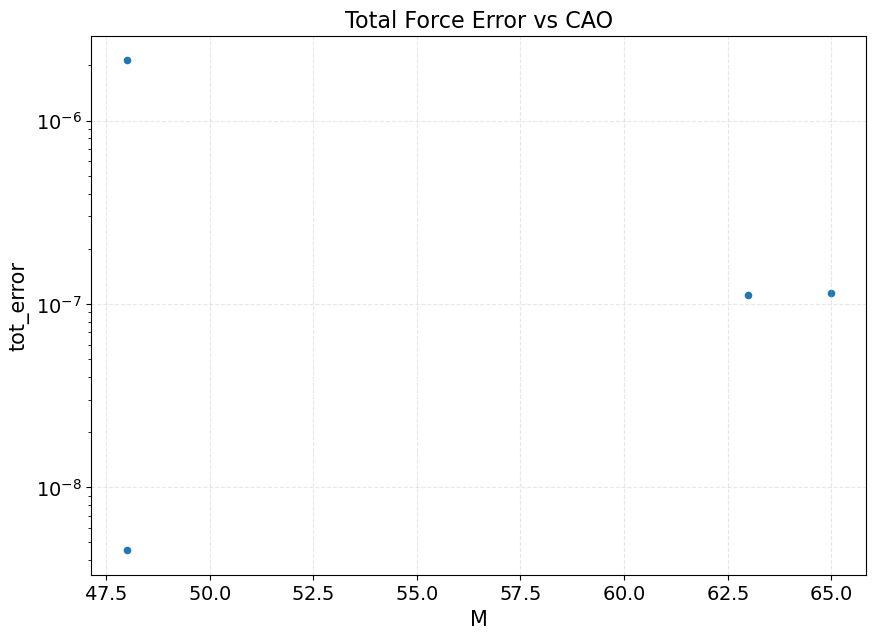

In [17]:
display(optimizer.valid_solutions_df)
optimizer.valid_solutions_df.plot(x = 'M', y = 'tot_error', kind='scatter', logy=True, title='Total Force Error vs CAO')

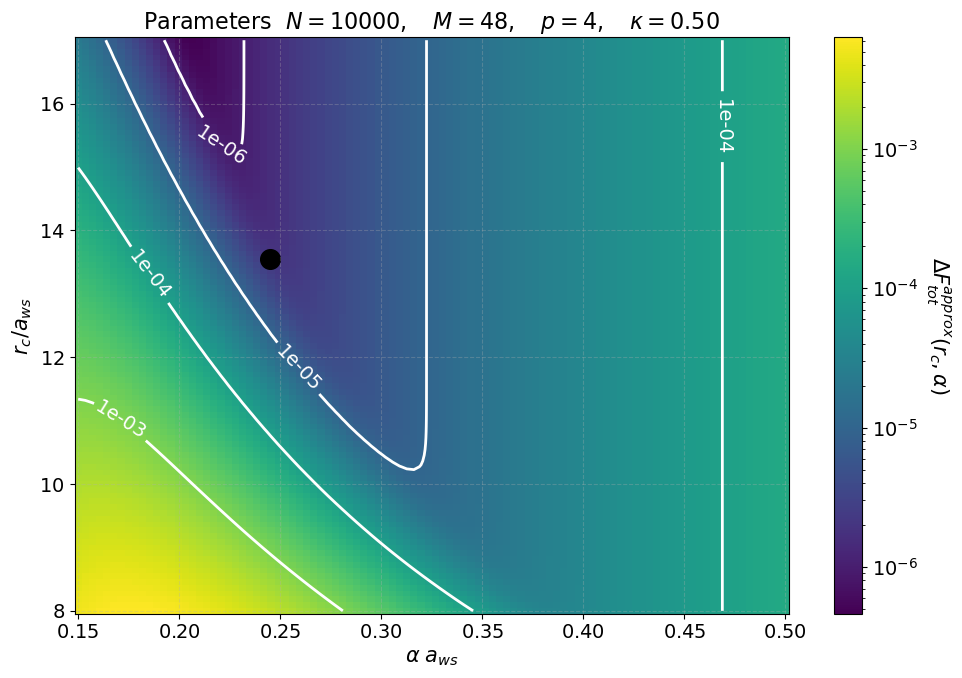

In [27]:
optimizer.plot_error_surface(
    rc=optimizer.valid_solutions_df['rc'].loc[0],
    alpha=optimizer.valid_solutions_df['alpha'].loc[0],
    M= optimizer.valid_solutions_df['M'].loc[0],
    cao= optimizer.valid_solutions_df['cao'].loc[0],
    rc_range= (8, 17),
    alpha_range=(0.15, 0.5)
)

In [ ]:
# Fit the pp time
from scipy.optimize import minimize, curve_fit


# Downselect the data to the relevant columns and scaled it
new_data = configuration_df[['r_cut', 'pppm_alpha_ewald', 'pppm_cao_x', 'M_x', 'pp_acc_time [s]', 'pm_acc_time [s]', 'tot_acc_time [s]', 
             'pppm_pp_error [measured]', 'pppm_pm_error [measured]', 'force error [measured]']]

new_data.loc[:, 'pppm_alpha_ewald'] *= preproc.parameters.a_ws
new_data.loc[:, 'r_cut'] /= preproc.parameters.a_ws
# new_data.loc[:, 'h_x'] /= preproc.parameters.a_ws

# ------------ Find the timing parameters----------------

def pp_time(r_cut, a1):
    return a1 * r_cut**3

def pm_time(M, cao, a2, a3, a4, a5):
    return a2 + a3 * cao**3 + a4 * M * np.log(M) + a5 * M**2

# Find the parameters by minimizing the residuals
def residuals(params, x, y):
    return np.sum((y - pp_time(x, *params))**2)

def residuals_pm(params, x1, x2, y):
    return np.sum((y - pm_time(x1, x2, *params))**2)

# Fit the pp time
p0 = [1.0]
result = minimize(residuals, p0, args=(new_data['r_cut'], new_data['pp_acc_time [s]']))
# Print the results
print('PP Timing Optimization parameters:')
print(result)
# Collect the parameters
a1 = result.x[0]
# Make a plot of the prediction vs the data
fig, ax = plt.subplots()
ax.plot(new_data['r_cut'], new_data['pp_acc_time [s]'], 'o', label='Data')
ax.plot(new_data['r_cut'], pp_time(new_data['r_cut'], a1), label='Prediction')
ax.set_xlabel('r_cut')
ax.set_ylabel('PP time [s]')
ax.legend()

# Fit the pm time
p0 = [1.0, 1.0, 1.0e-2, 1.0e-6]
result_pm = minimize(residuals_pm, p0, args=(new_data['M_x'], new_data['pppm_cao_x'], new_data['pm_acc_time [s]']))
# Print the results
print('\nPM Timing Optimization parameters:')
print(result_pm)

# Collect the parameters
a2 = result_pm.x[0]
a3 = result_pm.x[1]
a4 = result_pm.x[2]
a5 = result_pm.x[3]

# make predictions
pm_time_pred = pm_time(new_data['M_x'], new_data['pppm_cao_x'], a2, a3, a4, a5)
rmse = np.sqrt((new_data['pm_acc_time [s]'] - pm_time_pred)**2)

# Make a colormap of the RMSE
fig, ax = plt.subplots()
sc = ax.scatter(new_data['M_x'], new_data['pppm_cao_x'], c=rmse, cmap='viridis')
ax.set_xlabel('M_x')
ax.set_ylabel('Cao')
ax.set_title('PM RMSE')
plt.colorbar(sc)

In [ ]:
from sarkas.utilities.maths import force_error_analytic_pp, force_error_approx_pm

ratio_ = new_data["tot_acc_time [s]"] / new_data["force error [measured]"]
ratio = ratio_.mean()
print(f"Ratio of total time to force error: {ratio:.6e}")
kappa = preproc.potential.a_ws / preproc.potential.screening_length
print(f"Ratio of kappa to a_ws: {kappa:.6e}")

def force_error(r_cut, alpha, h, cao):

    rescaling = np.sqrt(3.0 / (4.0 * np.pi) ) 
    pp_err = force_error_analytic_pp(preproc.potential.type, r_cut, kappa, alpha, rescaling)

    pm_err = force_error_approx_pm(kappa, cao, h, alpha, rescaling)
    return np.sqrt(pp_err**2 + pm_err**2)


def loss_func(params):
    rc, M, cao, alpha = params
    # Calculate the timing and force error
    cao = int(cao)
    timing = pp_time(rc, a1) + pm_time(int(M), cao, a2, a3, a4, a5)
    
    h = preproc.parameters.box_lengths[0] / int(M) / preproc.parameters.a_ws
    force = force_error(rc, alpha, h, cao)
    
    return abs(timing + 1e-3 * ratio* np.log(force/1e-6))


# Initial guess for the parameters
p0 = [new_data['r_cut'].mean(), int(new_data['M_x'].mean()), int(new_data['pppm_cao_x'].mean()), new_data['pppm_alpha_ewald'].mean()]
# Min bound of rcut is 
min_rc = 4.0
max_rc = preproc.parameters.box_lengths[0] / 2.1 / preproc.parameters.a_ws
# Bounds for M
min_M = 16
max_M = 128
# Bounds of cao
min_cao = 3
max_cao = 7
# Bounds of alpha
min_alpha = 0.5 * preproc.parameters.a_ws/ preproc.parameters.box_lengths[0]
max_alpha = 10.0 * preproc.parameters.a_ws/ preproc.parameters.box_lengths[0]

bounds = [(min_rc, max_rc), (min_M, max_M), (min_cao, max_cao), (min_alpha, max_alpha)]

result = minimize(loss_func, p0, bounds=bounds)
print(result)

# print(f"Optimal time: )
# Rescale the parameters
rc = result.x[0] #* preproc.parameters.a_ws
M = int(result.x[1])
cao = int(result.x[2])
alpha = result.x[3] #/ preproc.parameters.a_ws

print(f"Optimal parameters: r_cut = {rc:.6f}, M = {M}, cao = {cao}, alpha = {alpha:.6f}")
print(f"Optimal timing: {pp_time(rc, a1) + pm_time(M, cao, a2, a3, a4, a5):.6f} s")
# Print h alpha
h = preproc.parameters.box_lengths[0] / M / preproc.parameters.a_ws
print(f"Optimal h: {h:.6f}")
print(f"Optimal force error: {force_error(rc, alpha, h, cao):.6e}")

In [ ]:
# bounds,
f"{2.669862 + 1e-3 * ratio * np.log(6.153875e-07/1e-6):.3e}"

In [ ]:
# Rescale the parameters
rc = result.x[0] * preproc.parameters.a_ws
M = int(result.x[1])
cao = int(result.x[2])
alpha = result.x[3] / preproc.parameters.a_ws

print(f"Optimal parameters: r_cut = {rc:.6e}, M = {M}, cao = {cao}, alpha = {alpha:.6e}")

## Simulation Estimates

The `PreProcess` class has two primary roles: help in the decision of the above parameters and provide an estimate time of the various phases of a simulation. 

The following line of code runs 20 + 1 timesteps of the equilibration, magnetization (in the case of a magnetized plasma simulation), and production phase to estimate the time of each timesteps, the time of each phase, the time of the entire simulation, and the size of all the dump files. The last line, instead, removes the dump files that have been saved in order to save space. 

In [ ]:
preproc.time_n_space_estimates(loops = 20)
preproc.remove_preproc_dumps()

### Times Estimates
It shows the times needed for the force calculation and the average time for an equilibration and production time step. 

As you can see the calculation of the optimal Green's function takes a relatively long time. Fortunately this needs be calculated only once at the beginning of the simulation. Note also that the PP part takes more than the time it takes for the PM part. This is specific to this hardware and the opposite case could be true on other machines.

Next Sarkas will run `loops = 20` timesteps for each phase to estimate the time of each. These are indicated by the green bars, a nice feature from the `tqdm` package. 
Note that the actual number of loops displayed is 21 instead of 20. The first timestep takes longer than the others because this is the first time that Numba is called. Therefore in order to avoid a skewed mean Sarkas runs one more timestep and averages over the last 20 loops only. 

>**_IMPORTANT:_** Note that the argument `loops` should be chosen to be larger than `production_dump_step` in order to get a more accurate estimate and not receive an error.

Below the green bars we find the average time of each phase. The equilibration phase takes longer than the production phase due to the presence of a thermostat.

At the end all the estimates are put together to calculate the equilibration, production, and total run times.

The equilibration and production times are then calculated by multiplying the above times by `equilibration_steps` and `production_steps`, respectively. 

>**_NOTE:_**  These times will vary depending on the computer hardware. For this tutorial we used a desktop with Intel Core i7-8700K @ 3.70Ghz and 48GB of RAM running Ubuntu 18.04.

### Filesize Estimates
Next Sarkas will estimate the size of the simulation. It calculates the size of the equilibration and a production HDF5 files. As mentioned above the last line takes care of removing dump files in order to save space.

This simulation should take about ~382 MB of space.

## Simulation Parameters Optimization

Plasmas main characteristic is the long range Coulomb interaction between particles. Sarkas uses the generalized PPPM algortihm which requires several parameters. The most important ones are: the short-range cut-off ($r_c$), the Ewald parameter ($\alpha$), the number of mesh points per direction ($M_x, M_y, M_z$).

MD simulations are often performed with sub-optimal parameters which lead to inefficient and (probably) longer runs. Furthermore, optimal parameters are not easily found as they depend not only on the type of problem under investigation, but also on the available computational hardware. Researchers are thus left to use trial-and-error approaches or rely on colleagues’ suggestions to choose simulation’s parameters.

Sarkas `PreProcessing` class aims at simplifying the search for optimal parameters. In order to find the optimal parameters we need to define a metric. Sarkas has chosen the simulation time and force error as metrics to choose the optimal parameters.

In the most general case there are eleven parameters to be optimized, but in our case we limit only to cubic simulation boxes which reduces the number of parameters to five. The optimization of these parameters goes as follows. 
* Calculate the time and force error for each combination of the parameters on a coarse parameters grid. 
* Fine tune the parameters starting from the best results from the coarse grid.

The following code runs few simulation timesteps for each of the combination of PPPM parameters and calculates their average time and force error. 
This will take a while.


This routine can be run directly in the `.run` method simply by setting the option `timing_study = True`.


In [ ]:
# Create the coarse parameter grid.
# We limit ourselves only to choosing the mesh size and number of cells of the linked-cell-lists 
# since the cutoff radius, `rc`, and the Ewald parameter, `pppm_alpha_ewald`, can be calculated from them. 
pm_meshes = np.logspace(3, 7, 6, base = 2,  dtype=np.int64) # !!!! Make sure to include the dtype = int64
pp_cells = np.array([3, 4, 5, 6], dtype=np.int64)
pm_caos = np.array([3, 4, 5, 6, 7], dtype=np.int64)  # Commented out for speed 

# # Call the timing study calculation with the coarse parameter grid
# preproc.timing_study_calculation(
#     target_error=1e-6, # Optional default is 1e-5
#     pp_cells=pp_cells, # Optional
#     pm_meshes=pm_meshes, # Optional
#     pm_caos=pm_caos, # Optional
#     )


### Timing Study
As mentioned above Sarkas calculates the force error and the computation times for the combination of parameters: mesh sizes, charge assignment order (cao) and lcl cells. The array of mesh sizes and cao can be changed by setting `preproc.pm_meshes` and `preproc.pm_caos` to the desired arrays. For each mesh size Sarkas sets 

        pppm_alpha_ewald = 0.3 * m / parameters.box_lengths.min()

and then calculates `pp_cells` as given by

        max_cells = int(0.5 * parameters.box_lengths.min() / parameters.a_ws)
        pp_cells = np.arange(3, max_cells, dtype=int)

Since this is a long process Sarkas prints out to screen the progress. At the end Sarkas saves all the information into a dataframe. The last line in the output tells you where to find it. 

Let's print the first ten lines

In [ ]:
preproc.dataframe.head(10)

Let's make some plots

In [ ]:
preproc.make_timing_plots()

The plot on the right is a plot of the computation times of the PP for part as a function of LCL cells for different mesh sizes. It looks like the mesh size does not affect the PP time significantly. This is because the LCL algorithm's time scales as

$$ \tau_{\rm LCL} \propto \left (\frac{4\pi n}{3} \frac{L^3}{N_c^3} \right ) N,$$

where $N_c = L/r_c$ is the number of cells per dimension (assumed to be the same in all directions) obtained from the cutoff radius, $r_c$. 

The center plot is a log-log plot of the times of the PM part as a function of the mesh size (`M_x = M_y = M_z`) for different `pppm_cao` values. Note that the xticks are given in powers of 2. This is because FFT algorithms are the most efficient when the number of mesh points is a multiple of a power of 2. However, in order to give a more realistic estimate, we have chosen mesh sizes that are not multiple of powers of 2. At fixed `pppm_cao` the FFT computation time scales as 

$$ \tau_{\rm FFT} \propto (M_x M_y M_z) \log_2( M_x M_y M_z). $$

This equation comes from the FFTW documentation [page](http://www.fftw.org/benchfit). The vertical variation in times is due to the interpolation of the charge density on the mesh and as such depends on the value of `pppm_cao` (assumed that `pppm_cao = pppm_cao_x = pppm_cao_y = pppm_cao_z`),

Finally, the left plot shows the time required to compute the optimal Green's function as a function of the mesh size at different `pppm_cao` values. This time again does not depend strongly on the value of `pppm_cao` since in this case there is no loop on `pppm_cao` and it only appears as the exponent the computation of the Green's function.

Note that currently the `timing_study_calculation` method uses cubic meshes, Sarkas dev team is hoping to improve this method to include different geometries. PR are welcome!

Let's make some more plots.

In [ ]:
preproc.make_force_v_timing_plot()

The above figures are color maps of total force error (left) and the total acceleration time (right) as functions of the LCL cells and mesh size (`M_x`). There is a plot for each `pppm_cao_x`. 
The force error is given by $\Delta F_{\rm tot}$

$$ \Delta F_{\textrm{tot}} = \sqrt{ \Delta F_{\rm PP}^2 + \Delta F_{\rm PM}^2 }, $$

where $\Delta F_{\rm PP(PM)}$ is the force error of the PP (PM) part, see [Force Error](../../theory/force_error.rst) for more details.

These maps are created using `matplotlib.pyplot.contourf()` function by passing the data in the columns `tot_acc_time [s]` and `force_error [measured]` of the dataframe and interpolating using `scipy.interpolate.griddata`, hence, the staggered contour lines.

As expected the maps indicate that the smaller the force error the larger the computation time. These plots are meant to provide an overview of the parameter space and help you decide the optimal value for $ M_x $ and $ N_c $.

The black dot in the second to last figure indicates our original choice of paramaters. If we pay close attention we notice that the force error is larger than the one calculated in the beginnning of this notebook. This is because while the number of cells is the same in both case the cutoff radius is not. The cutoff radius chosen in the input file is smaller than the one used for producing the above plots which is calculated from $r_c = L/N_c$. 

In order to fine tune our choice of parameters we run the next line


In [ ]:
preproc.pppm_approximation()

### Force Error
The first figure is a contour map in the $(r_c,\alpha)$ parameters space of 

$$ \Delta F_{\textrm{tot}}^{(\textrm{approx})}( r_c, \alpha) = \sqrt{ \Delta F_{\rm PP}^2 +
            ( \Delta F_{\rm PM}^{(\textrm{approx})} ) ^2 }. $$
            
$\Delta F_{\rm PM}^{(\textrm{approx})}$ is calculated from an approximation of the PM force error, hence the superscript $\rm approx$, and its functional form is different than the one calculated in $\Delta F_{\rm PM}$, see [Force Error](../../theory/force_error.rst) for more detail. The numbers on the white contours indicate the value of $\Delta F_{\textrm{tot}}^{(\textrm{apprx})}$ along those lines and the black dot, again, indicates our choice of parameters. Notice that our parameter choice now falls in the region in between `1e-5` and `1e-6` as expected, recall `Tot Force Error = 6.442673e-06`. This plot tells us that if we want a force error of the order 1e-6 we need to choose values that fall into the small purple triangle at the top.

However, our choice of parameters while being good, it might not be optimal. In order to find the best choice we look at the second figure.

The left panel is a plot of $\Delta F_{\textrm{tot}}^{(\textrm{approx})}$ vs $r_c/a_{\rm ws}$ at
five different values of $\alpha a_{\rm ws}$ while the right panel is a plot of
$\Delta F_{\textrm{tot}}^{(\textrm{approx})}$ vs $\alpha a_{\rm ws}$ at five different values of $r_c/a_{\rm ws}$. The vertical black dashed lines indicate our choice of $\alpha a_{\rm ws}$ and $r_c/a_{\rm ws}$. The horizontal black dashed lines, instead, indicate the value `Tot Force Error = 6.442673e-06`.

These plots show that our analytical approximation is a very good approximation and that our choice of parameters is optimal as the intersection of the dashed lines falls exactly in the minimum of the curves. From the left panel we find that larger values for $r_c = 5.51$ lead to an inefficient code since we will be calculating the interaction for many more particles without actually reducing the force error. Similarly, the right panel shows that our choice of $r_c$ is close to optimal given $\alpha a_{ws} = 0.614$.

Some good rules of thumb to keep in mind while choosing the parameters are

- larger (smaller) $\alpha$ lead to a smaller (larger) PM error, but to a larger (smaller) PP error,
- larger (smaller) $r_c$ lead to a smaller (greater) PP part but do not affect the PM error,
- keep an eye on the PM and PP calculation times.
- larger $r_c$ lead to a longer time spent in calculating the PP part of the force since there are more neighbors,
- larger or smaller $\alpha$ do not affect the PM calculation time since this depends on the number of mesh points,
- choose the number of mesh points to be a power of 2 since FFT algorithms are most efficient in this case.

>**_NOTE:_**  The above investigation is useful in choosing the parameters $r_c$ and $\alpha$ for fixed values of the charge approximation order, $p$, the number of mesh points, $M_x = M_y = M_z$, and number of aliases $m_x = m_y = m_z$.


## Post Processing

All the above information are needed in order to run a simulation and produce data to be analyzed in the post-processing phase. However, the optimal choice of the above parameters does not necessarily indicate that our desired physical observable is calculated correctly. Thus, we need to verify that our choices lead to the desired physical result.

Let's run the next code cell to print the parameters of the physical observables that we decided to calculate in the `PostProcessing` section of the YAML file. 

In [ ]:
# preproc.postproc_estimates()

### Radial Distribution Function

The most common physical observable is the Radial Distribution Function (RDF). Our choice of `Parameters.rdf_nbins : 500` and `Potential.rc : 6.2702e-11` leads to `dr = 0.0110 a_ws` and `r_max = 5.5100 a_ws`. If we desire to have a larger `r_max` we will need to increase `potential.rc`. As mentioned above this might lead to an inefficient force calculation, but the force error plots can help us find an optimal `alpha` for a larger `rcut`

### Static Structure Factor

The Fourier transform of the RDF leads to the Static Structure Factor (SSF). The important parameters for the SSF is the desired range of wavevectors to calculate. The output shows the chosen number of harmonics of the smallest wavevector in each of cartesian directions. These are the same values in the YAML file. 

Next, we find the total number of $\mathbf k$ (vectors) that will be calculated. This number corresponds to the total number of combinations of the three harmonics directions, `n_x * n_y * n_z - 1` .

The smallest $\mathbf k$ vector that can be fitted int the simulation box is given by the length of the longest side of the simulation box, $L$. This is computed from the total number of particles, $N$.

$$ k_{\rm min} = \frac{2\pi}{L} \approx \frac{3.9}{N^{1/3}}$$

In this case, $k_{\rm min} a_{\rm ws} = 0.1809 $, if we need to investigate smaller wavevectors we need to increase the number of particles. The above equation can be used to find the value of $N$ for the desired $k_{\rm min}$ value.

The largest wavevector, instead, is defined by our choice of `angle_averaging`. This parameter can take three values `principal_axis`, `custom`, `full`. The default value for this parameter is `principal_axis`. More about this parameter will be explained in the [Post Processing notebook](./Post_Processing_Docs.ipynb). For the moment we mention that in the case of `angle_averaging = principal_axis` the maximum value is calculated as

$$ k_{\rm max} = \frac{2 \pi}{L} \sqrt{3} n_x, $$

while in the case `angle_averaging = full` as

$$ k_{\rm max} = \frac{2 \pi}{L} \sqrt{n_x^2 + n_y^2 + n_z^2}. $$

### Dynamic Structure Factor and Current Correlation Function

These two functions depend on the same parameters. However, it can be the case that only one of the two is calculated, hence, a section for each of them. The parameters are divided in two sections, frequency and wavevector constants. The wavevectors constants are the same as those in SSF. This is due to the fact that the $\mathbf k$ data is saved once computed the first time. Any subsequent calculation requiring this data will read in the saved data and not recompute it. Therefore it is important to check that the parameters in the YAML file are the same. 

As per the frequency constants, the first parameters is the number of slices. This indicates the number in which to divide the timeseries data. A DSF (or CCF) will be calculated for each slice and the final result will be an average over all the slices. The important parameters are then the frequency step and the maximum frequency calculated from the FFT. For each of these values, the corresponding equation is given so to help the user decide the correct parameters.
The maximum frequency is given by 
 
$$ \omega_{\rm max} = \frac{\pi}{d_s \Delta t } $$

where $\Delta t$ is the timestep and $d_s$ the snapshot interval (`prod_dump_step`). The frequency step instead is 

$$ \Delta \omega = 2\pi \frac{d_s N_s}{M_T \Delta t} $$

where $N_s$ is the number of slices (`no_slices`), $M_T$ the number of timesteps (`production_steps`).

## Put it all together


All the above methods can be automatically run by seeting options to true in the `PreProcess.run()` method. 

    preproc.run(
        timing=True,          # time estimation, default is True
        loops = 20,           # the number of timesteps to average, Default is 10
        timing_study = True,  # Run the timing_study_calculation. Default is False
        pppm_estimate = True, # Run pppm_approximation. Default is False
        remove = True,        # Save some space. Default is False
        postprocessing = True # Run postproc_estimates. Default is False.
               )
